# Coastal Shoreline Threshold Research Notebook

**Location:** Waskaduwa Beach, Kalutara, Sri Lanka
**Period:** 2012 – 2024 (12 monsoon-year intervals)

**Objective:** Learn shoreline-response threshold ranges from **filename-defined shoreline intervals** and **monthly wave, wind, and current patterns**, then forecast **future erosion-side and accretion-side threshold ranges directly** from historical threshold trajectories.

## Core Workflow

1. **Monthly Dataset Conversion** — Convert Wave, Wind, and Current NetCDFs to a consistent monthly forcing table.
2. **DSAS Transect → Year Labels** — Build five-class shoreline interval labels using the CSV file name year as the correct annual key.
3. **Five-Class Shoreline Target** — Keep `eroded_high`, `eroded_low`, `stable`, `accreted_low`, and `accreted_high` as the ordered shoreline response classes.
4. **Monthly Pattern Signatures** — Extract within-interval monthly forcing anomaly features per shoreline interval (full April–March monsoon year).
5. **Five-Class Pattern Recognition** — Screen and train ordered and multiclass models on the monthly pattern signatures using Leave-One-Out cross-validation.
6. **Threshold Range Estimation** — Estimate four boundary thresholds per driver: `severe_erosion`, `erosion_onset`, `accretion_onset`, `strong_accretion`, with bootstrap confidence intervals.
7. **Direct Threshold Forecasting** — Forecast threshold trajectories themselves 24 months ahead (H6, H12, H18, H24) using TheilSen regression on the historical threshold history.

## Data Inputs

1. **DSAS Shoreline CSVs** — Transect-based shoreline statistics from the QGIS/DSAS workflow. File names are the authoritative interval years.
2. **Wave NetCDF** — Monthly wave forcing variables (VHM0, VTPK, VMDR, VSDX, VSDY).
3. **Wind NetCDF** — Monthly sea-surface wind forcing variables (wind_speed, eastward_wind, northward_wind).
4. **Current NetCDF** — Monthly ocean-current forcing variables (uo, vo, zos).

## Research Note

If a shoreline class is absent in the historical annual labels, the notebook keeps that class in the ordered framework but reports the corresponding thresholds as unsupported rather than inventing values.


## Section 0 — Environment Setup & Data Loading

Import all required libraries and load the four datasets that drive the entire analysis.

**Data inputs:**
1. **DSAS Shoreline CSVs** (`notebook_data/*-stat.csv`) — Transect NSM/EPR statistics from QGIS, one file per year-pair interval (12 files, 2012–2024)
2. **Wave NetCDF** — Global Ocean Waves Reanalysis 2009–2024 (VHM0, VTPK, VMDR, VSDX, VSDY)
3. **Wind NetCDF** — Sea Surface Wind & Stress from Scatterometer 2009–2024 (wind_speed, eastward_wind, northward_wind)
4. **Current NetCDF** — Global Ocean Physics Reanalysis 2009–2024 (uo, vo, zos)


In [1]:
# =============================================================================
# Section 0.1 — Import All Required Libraries
# =============================================================================
# All imports are consolidated here so every section below can run cleanly.
# Libraries from older binary-workflow code have been removed.

# ── Standard library ──────────────────────────────────────────────────────────
import os
import warnings
from pathlib import Path
from datetime import datetime

# ── Numeric and data ──────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import xarray as xr                     # reading NetCDF datasets (wave, wind, current)
import matplotlib.pyplot as plt
import seaborn as sns

# ── Statistical tests ─────────────────────────────────────────────────────────
# scipy.stats   — used in bootstrap CI (Section 1)
# kruskal       — Kruskal-Wallis feature screening (Section 3.2)
# spearmanr     — Spearman rank correlation for ordered screening (Section 3.2)
from scipy import stats
from scipy.stats import kruskal, spearmanr

# ── Scikit-learn: pattern recognition + threshold forecasting ─────────────────
from sklearn.ensemble import RandomForestClassifier      # Section 3.2
from sklearn.linear_model import (
    LogisticRegression,      # Section 3.2 — multinomial softmax baseline
    TheilSenRegressor,       # Section 3.4 — robust trend for threshold forecasting
)
from sklearn.metrics import balanced_accuracy_score, confusion_matrix, f1_score
from sklearn.model_selection import LeaveOneOut          # Section 3.2 — LOOCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif  # Section 3.2 — MI screening

# ── Statsmodels: ordered logit for threshold boundary estimation (Section 3.3) ─
from statsmodels.miscmodels.ordinal_model import OrderedModel
from statsmodels.tools.sm_exceptions import ConvergenceWarning, HessianInversionWarning

# Suppress convergence/inversion warnings from ordered logit fitting
warnings.filterwarnings('ignore', category=ConvergenceWarning)
warnings.filterwarnings('ignore', category=HessianInversionWarning)
warnings.filterwarnings('ignore')

# ── Output directories ────────────────────────────────────────────────────────
os.makedirs('./figures', exist_ok=True)
os.makedirs('./outputs', exist_ok=True)

# ── Matplotlib style ──────────────────────────────────────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14

print("✓ Libraries loaded")


✓ Libraries loaded


In [2]:
# =============================================================================
# Section 0.2 — Load all datasets
# =============================================================================

from pathlib import Path

DATA_PATH = Path("notebook_data")
SHORELINE_GLOB = "*-stat.csv"
WAVE_FILE = DATA_PATH / "Global_Ocean_Waves_Reanalysis_2009_2024.nc"
WIND_FILE = DATA_PATH / "Global Ocean Monthly Mean Sea Surface Wind and Stress from Scatterometer and Model_2009_2024.nc"
CURRENT_FILE = DATA_PATH / "Global Ocean Physics Reanalysis(current_data)_2009_2024.nc"


def parse_interval_from_filename(path_obj):
    start_token, end_token = path_obj.stem.replace("-stat", "").split("-")
    return 2000 + int(start_token), 2000 + int(end_token)


shoreline_interval_files = sorted(DATA_PATH.glob(SHORELINE_GLOB))
if not shoreline_interval_files:
    raise FileNotFoundError(f"No shoreline interval files matched {SHORELINE_GLOB!r} in {DATA_PATH}")

shoreline_interval_tables = {}
inventory_rows = []

for path_obj in shoreline_interval_files:
    start_year, end_year = parse_interval_from_filename(path_obj)
    interval_label = f"{start_year}-{end_year}"
    interval_df = pd.read_csv(path_obj)
    shoreline_interval_tables[interval_label] = interval_df

    metadata_years = sorted(
        set(interval_df['SCE_closest_year'].dropna().astype(int)).union(
            set(interval_df['SCE_farthest_year'].dropna().astype(int))
        )
    )
    inventory_rows.append({
        'interval': interval_label,
        'monsoon_year': start_year,
        'shoreline_year': end_year,
        'n_transects': len(interval_df),
        'metadata_years': ', '.join(map(str, metadata_years)),
        'metadata_matches_filename': metadata_years == [start_year, end_year],
        'NSM_unc': float(interval_df['NSM_highest_unc'].median()),
        'EPR_unc': float(interval_df['EPR_unc'].median()),
    })

shoreline_inventory = pd.DataFrame(inventory_rows).sort_values('monsoon_year').reset_index(drop=True)
latest_interval_label = shoreline_inventory.iloc[-1]['interval']

print("=" * 60)
print("SHORELINE DATA SUMMARY (YEAR-PAIR TRANSECT FILES)")
print("=" * 60)
print(f"Files loaded: {len(shoreline_interval_files)}")
print(f"Interval range: {shoreline_inventory.iloc[0]['interval']} to {shoreline_inventory.iloc[-1]['interval']}")
print("Indexing rule: use the file name interval as the canonical annual key.")

metadata_mismatch_count = int((~shoreline_inventory['metadata_matches_filename']).sum())
if metadata_mismatch_count > 0:
    print(
        f"Warning: {metadata_mismatch_count} files have internal DSAS year stamps that do not match the file name. "
        "The file name interval will be used for year-wise aggregation."
    )

display(shoreline_inventory)

# ── Load NetCDF datasets ──
wave_ds = xr.open_dataset(WAVE_FILE)
wind_ds = xr.open_dataset(WIND_FILE)
current_ds = xr.open_dataset(CURRENT_FILE)

for name, ds in [('Wave', wave_ds), ('Wind', wind_ds), ('Current', current_ds)]:
    print(f"\n{name}: {list(ds.data_vars)} | time {ds.sizes.get('time', '?')} steps")


SHORELINE DATA SUMMARY (YEAR-PAIR TRANSECT FILES)
Files loaded: 12
Interval range: 2012-2013 to 2023-2024
Indexing rule: use the file name interval as the canonical annual key.


,interval,monsoon_year,shoreline_year,n_transects,metadata_years,metadata_matches_filename,NSM_unc,EPR_unc
0,2012-2013,2012,2013,162,"2012, 2013",True,2.0,4.22
1,2013-2014,2013,2014,164,"2014, 2015",False,2.0,4.29
2,2014-2015,2014,2015,158,"2014, 2015",True,2.0,3.11
3,2015-2016,2015,2016,159,"2015, 2016",True,2.0,2.26
4,2016-2017,2016,2017,163,"2016, 2018",False,2.0,1.69
5,2017-2018,2017,2018,162,"2018, 2019",False,2.0,3.07
6,2018-2019,2018,2019,161,2019,False,2.0,5.77
7,2019-2020,2019,2020,160,"2019, 2021",False,2.0,2.42
8,2020-2021,2020,2021,164,"2021, 2022",False,2.0,2.11
9,2021-2022,2021,2022,163,"2021, 2022",True,2.0,2.11



Wave: ['VHM0', 'VHM0_SW1', 'VHM0_SW2', 'VHM0_WW', 'VMDR', 'VMDR_SW1', 'VMDR_SW2', 'VMDR_WW', 'VPED', 'VSDX', 'VSDY', 'VTM01_SW1', 'VTM01_SW2', 'VTM01_WW', 'VTM02', 'VTM10', 'VTPK'] | time 42601 steps

Wind: ['eastward_stress', 'eastward_stress_bias', 'eastward_stress_sdd', 'eastward_wind', 'eastward_wind_bias', 'eastward_wind_sdd', 'northward_stress', 'northward_stress_bias', 'northward_stress_sdd', 'northward_wind', 'northward_wind_bias', 'northward_wind_sdd', 'number_of_observations', 'wind_speed', 'wind_speed_bias', 'wind_speed_sdd', 'wind_stress_magnitude', 'wind_stress_magnitude_bias', 'wind_stress_magnitude_sdd'] | time 175 steps

Current: ['bottomT', 'mlotst', 'siconc', 'sithick', 'so', 'thetao', 'uo', 'usi', 'vo', 'vsi', 'zos'] | time 175 steps


### Section 0.3 — Dataset Variable Dictionary

This cell inspects all three oceanographic NetCDF datasets and displays each variable's **name**, **long name (meaning)**, **units**, and **shape**, providing a complete reference for the data used in this analysis.

In [3]:
# =============================================================================
# Section 0.3 — Dataset Variable Dictionary
# ============================================================================= 

# Reuse wave_ds, wind_ds, current_ds already loaded in Section 0.2

def inspect_dataset(ds, dataset_name):
    """Extract variable metadata from an xarray Dataset."""
    rows = []
    for var_name in sorted(ds.data_vars):
        v = ds[var_name]
        long_name = v.attrs.get('long_name', v.attrs.get('standard_name', 'N/A'))
        units = v.attrs.get('units', 'N/A')
        shape = dict(zip(v.dims, v.shape))
        rows.append({
            'Variable': var_name,
            'Description': long_name,
            'Units': units,
            'Dimensions': str(shape)
        })
    df = pd.DataFrame(rows)
    print("=" * 90)
    print(f"  {dataset_name}")
    print(f"  Source: {ds.attrs.get('source', ds.attrs.get('institution', 'N/A'))}")
    print(f"  Time range: {str(ds.time.values[0])[:10]} — {str(ds.time.values[-1])[:10]}")
    print(f"  Total variables: {len(ds.data_vars)}")
    print("=" * 90)
    display(df)
    print()
    return df

print("\n📋 OCEANOGRAPHIC DATASET VARIABLE DICTIONARY\n")

wave_var_info    = inspect_dataset(wave_ds,    "🌊 WAVE DATASET — Global Ocean Waves Reanalysis")
wind_var_info    = inspect_dataset(wind_ds,    "💨 WIND DATASET — Global Ocean Surface Wind & Stress")
current_var_info = inspect_dataset(current_ds, "🌀 CURRENT DATASET — Global Ocean Physics Reanalysis")


📋 OCEANOGRAPHIC DATASET VARIABLE DICTIONARY

  🌊 WAVE DATASET — Global Ocean Waves Reanalysis
  Source: METEO-FRANCE
  Time range: 2009-08-01 — 2024-02-29
  Total variables: 17


,Variable,Description,Units,Dimensions
0,VHM0,Spectral significant wave height (Hm0),m,"{'time': 42601, 'latitude': 1, 'longitude': 2}"
1,VHM0_SW1,Spectral significant primary swell wave height,m,"{'time': 42601, 'latitude': 1, 'longitude': 2}"
2,VHM0_SW2,Spectral significant secondary swell wave height,m,"{'time': 42601, 'latitude': 1, 'longitude': 2}"
3,VHM0_WW,Spectral significant wind wave height,m,"{'time': 42601, 'latitude': 1, 'longitude': 2}"
4,VMDR,Mean wave direction from (Mdir),degree,"{'time': 42601, 'latitude': 1, 'longitude': 2}"
5,VMDR_SW1,Mean primary swell wave direction from,degree,"{'time': 42601, 'latitude': 1, 'longitude': 2}"
6,VMDR_SW2,Mean secondary swell wave direction from,degree,"{'time': 42601, 'latitude': 1, 'longitude': 2}"
7,VMDR_WW,Mean wind wave direction from,degree,"{'time': 42601, 'latitude': 1, 'longitude': 2}"
8,VPED,Wave principal direction at spectral peak,degree,"{'time': 42601, 'latitude': 1, 'longitude': 2}"
9,VSDX,Stokes drift U,m s-1,"{'time': 42601, 'latitude': 1, 'longitude': 2}"



  💨 WIND DATASET — Global Ocean Surface Wind & Stress
  Source: Royal Netherlands Meteorological Institute (KNMI)
  Time range: 2009-08-01 — 2024-02-01
  Total variables: 19


,Variable,Description,Units,Dimensions
0,eastward_stress,Surface wind stress eastward component,N m-2,"{'time': 175, 'latitude': 1, 'longitude': 1}"
1,eastward_stress_bias,Scatterometer-model bias of surface wind stres...,N m-2,"{'time': 175, 'latitude': 1, 'longitude': 1}"
2,eastward_stress_sdd,Standard deviation of differences of surface w...,N m-2,"{'time': 175, 'latitude': 1, 'longitude': 1}"
3,eastward_wind,Stress-equivalent wind eastward component at 10 m,m s-1,"{'time': 175, 'latitude': 1, 'longitude': 1}"
4,eastward_wind_bias,Scatterometer-model bias of stress-equivalent ...,m s-1,"{'time': 175, 'latitude': 1, 'longitude': 1}"
5,eastward_wind_sdd,Standard deviation of differences of stress-eq...,m s-1,"{'time': 175, 'latitude': 1, 'longitude': 1}"
6,northward_stress,Surface wind stress northward component,N m-2,"{'time': 175, 'latitude': 1, 'longitude': 1}"
7,northward_stress_bias,Scatterometer-model bias of surface wind stres...,N m-2,"{'time': 175, 'latitude': 1, 'longitude': 1}"
8,northward_stress_sdd,Standard deviation of differences of surface w...,N m-2,"{'time': 175, 'latitude': 1, 'longitude': 1}"
9,northward_wind,Stress-equivalent wind northward component at ...,m s-1,"{'time': 175, 'latitude': 1, 'longitude': 1}"



  🌀 CURRENT DATASET — Global Ocean Physics Reanalysis
  Source: MERCATOR GLORYS12V1
  Time range: 2009-08-01 — 2024-02-01
  Total variables: 11


,Variable,Description,Units,Dimensions
0,bottomT,Sea floor potential temperature,degrees_C,"{'time': 175, 'latitude': 1, 'longitude': 1}"
1,mlotst,Density ocean mixed layer thickness,m,"{'time': 175, 'latitude': 1, 'longitude': 1}"
2,siconc,Ice concentration,1,"{'time': 175, 'latitude': 1, 'longitude': 1}"
3,sithick,Sea ice thickness,m,"{'time': 175, 'latitude': 1, 'longitude': 1}"
4,so,Salinity,1e-3,"{'time': 175, 'depth': 19, 'latitude': 1, 'lon..."
5,thetao,Temperature,degrees_C,"{'time': 175, 'depth': 19, 'latitude': 1, 'lon..."
6,uo,Eastward velocity,m s-1,"{'time': 175, 'depth': 19, 'latitude': 1, 'lon..."
7,usi,Sea ice eastward velocity,m s-1,"{'time': 175, 'latitude': 1, 'longitude': 1}"
8,vo,Northward velocity,m s-1,"{'time': 175, 'depth': 19, 'latitude': 1, 'lon..."
9,vsi,Sea ice northward velocity,m s-1,"{'time': 175, 'latitude': 1, 'longitude': 1}"


In [4]:
# =============================================================================
# Section 0.4 — Validate Required Variables & Data Quality
# =============================================================================
import numpy as np

required_vars = {
    "🌊 Wave Dataset": {
        "dataset": wave_ds,
        "variables": ["VHM0", "VMDR", "VSDX", "VSDY", "VTPK"]
    },
    "💨 Wind Dataset": {
        "dataset": wind_ds,
        "variables": ["eastward_wind", "northward_wind", "wind_speed"]
    },
    "🌀 Current Dataset": {
        "dataset": current_ds,
        "variables": ["uo", "vo", "zos"]
    }
}

print("=" * 100)
print("  DATASET VARIABLE VALIDATION & DATA QUALITY CHECK")
print("=" * 100)

all_valid = True
for ds_name, info in required_vars.items():
    ds = info["dataset"]
    available = list(ds.data_vars)
    print(f"\n{ds_name}")
    print(f"  Available variables: {available}")
    header = f"  {'Variable':<20} {'Status':<12} {'Total':<10} {'Valid':<10} {'NaN/Null':<10} {'NaN %':<8} {'Min':<12} {'Max':<12} {'Mean':<12}"
    print(header)
    print(f"  {'-'*118}")
    for var in info["variables"]:
        if var in available:
            v = ds[var]
            vals = v.values.flatten()
            total = len(vals)
            nan_count = int(np.isnan(vals).sum())
            valid_count = total - nan_count
            nan_pct = (nan_count / total * 100) if total > 0 else 0
            valid_vals = vals[~np.isnan(vals)]
            if len(valid_vals) > 0:
                v_min = f"{np.nanmin(valid_vals):.4f}"
                v_max = f"{np.nanmax(valid_vals):.4f}"
                v_mean = f"{np.nanmean(valid_vals):.4f}"
            else:
                v_min = v_max = v_mean = "—"
            status = "✅ Good" if nan_pct < 50 else "⚠️ Sparse" if nan_pct < 100 else "❌ Empty"
            if nan_pct > 0 and nan_pct < 100:
                status = f"⚠️ {nan_pct:.1f}%null"
            elif nan_pct >= 100:
                status = "❌ AllNull"
                all_valid = False
            else:
                status = "✅ Good"
            print(f"  {var:<20} {status:<12} {total:<10} {valid_count:<10} {nan_count:<10} {nan_pct:<8.1f} {v_min:<12} {v_max:<12} {v_mean:<12}")
        else:
            print(f"  {var:<20} {'❌ Missing':<12} {'—':<10} {'—':<10} {'—':<10} {'—':<8} {'—':<12} {'—':<12} {'—':<12}")
            all_valid = False

print("\n" + "=" * 100)
if all_valid:
    print("  ✅ All required variables are present with valid data.")
else:
    print("  ⚠️  Some variables are MISSING or contain ALL null values — check dataset files.")
print("=" * 100)

  DATASET VARIABLE VALIDATION & DATA QUALITY CHECK

🌊 Wave Dataset
  Available variables: ['VHM0', 'VHM0_SW1', 'VHM0_SW2', 'VHM0_WW', 'VMDR', 'VMDR_SW1', 'VMDR_SW2', 'VMDR_WW', 'VPED', 'VSDX', 'VSDY', 'VTM01_SW1', 'VTM01_SW2', 'VTM01_WW', 'VTM02', 'VTM10', 'VTPK']
  Variable             Status       Total      Valid      NaN/Null   NaN %    Min          Max          Mean        
  ----------------------------------------------------------------------------------------------------------------------
  VHM0                 ✅ Good       85202      85202      0          0.0      0.5700       4.3400       1.6063      
  VMDR                 ✅ Good       85202      85202      0          0.0      0.4300       353.7100     199.6424    
  VSDX                 ✅ Good       85202      85202      0          0.0      -0.1000      0.2100       0.0400      
  VSDY                 ✅ Good       85202      85202      0          0.0      -0.1800      0.1900       0.0085      
  VTPK                 ✅ Good

## Section 1 — DSAS Year-Pair Classification to Research-Grade Annual Labels

This section converts the uploaded **year-pair DSAS transect files** into **monsoon-year coastal change labels**.

**Method used in this notebook**
1. Treat the **file name interval** as the canonical year key (for example, `2012-2013` maps to monsoon year `2012`).
2. Classify each transect using **uncertainty-aware NSM thresholds** and an **EPR direction consistency check**.
3. Aggregate each interval with a **10% trimmed mean NSM** and a **bootstrap 95% confidence interval**.
4. Assign the final yearly class only when the interval-scale signal is clearly outside the uncertainty band; otherwise label it **stable**.

| Class | Annual NSM Rule | Interpretation |
|-------|------------------|----------------|
| Eroded High | 95% CI remains below −3 m | Severe retreat |
| Eroded Low | 95% CI remains below −1 m | Persistent retreat |
| Stable | CI overlaps 0 m or stable share dominates | Within noise / mixed response |
| Accreted Low | 95% CI remains above +1 m | Persistent advance |
| Accreted High | 95% CI remains above +3 m | Strong advance |


In [5]:
# =============================================================================
# Section 1.1 — DSAS Year-Pair Transect Files → 5-Class Annual Shoreline Labels
# =============================================================================
# Reads each year-pair CSV (e.g. 12-13-stat.csv = monsoon year 2012).
# Classifies each transect using NSM ± uncertainty and EPR direction.
# Aggregates to interval-level with a 10% trimmed mean + bootstrap 95% CI.
# Assigns the final 5-class label only when the CI clearly falls outside the
# stable zone; otherwise labels the interval 'stable'.
# =============================================================================

# ── NSM class boundaries (metres) ────────────────────────────────────────────
HIGH_EROSION_THRESHOLD   = -3.0   # eroded_high:   CI stays below this
LOW_EROSION_THRESHOLD    = -1.0   # eroded_low:    CI stays below this
LOW_ACCRETION_THRESHOLD  =  1.0   # accreted_low:  CI stays above this
HIGH_ACCRETION_THRESHOLD =  3.0   # accreted_high: CI stays above this

TRIM_FRACTION    = 0.10    # 10% trimmed mean for robust NSM average
BOOTSTRAP_SAMPLES = 2000   # bootstrap iterations for 95% CI
BOOTSTRAP_SEED    = 42

# Ordered class labels (negative = erosion, positive = accretion)
CLASS_SCORE_MAP = {
    'eroded_high': -2, 'eroded_low': -1, 'stable': 0,
    'accreted_low': 1, 'accreted_high': 2,
}
SCORE_CLASS_MAP = {score: label for label, score in CLASS_SCORE_MAP.items()}


# ── Helper functions ──────────────────────────────────────────────────────────

def classify_nsm(nsm):
    """Classify a single NSM value without accounting for uncertainty."""
    if nsm < HIGH_EROSION_THRESHOLD:    return 'eroded_high'
    if nsm < LOW_EROSION_THRESHOLD:     return 'eroded_low'
    if nsm <= LOW_ACCRETION_THRESHOLD:  return 'stable'
    if nsm <= HIGH_ACCRETION_THRESHOLD: return 'accreted_low'
    return 'accreted_high'


def classify_with_uncertainty(value, uncertainty):
    """Classify NSM using ± uncertainty band (conservative — steps toward stable when uncertain)."""
    uncertainty = 0.0 if pd.isna(uncertainty) else float(uncertainty)
    lower, upper = value - uncertainty, value + uncertainty
    if upper < HIGH_EROSION_THRESHOLD:    return 'eroded_high'
    if upper < LOW_EROSION_THRESHOLD:     return 'eroded_low'
    if lower > HIGH_ACCRETION_THRESHOLD:  return 'accreted_high'
    if lower > LOW_ACCRETION_THRESHOLD:   return 'accreted_low'
    return 'stable'


def direction_with_uncertainty(value, uncertainty):
    """Return −1 (retreat), +1 (advance), or 0 (uncertain) given ± uncertainty."""
    uncertainty = 0.0 if pd.isna(uncertainty) else float(uncertainty)
    if value + uncertainty < 0: return -1
    if value - uncertainty > 0: return  1
    return 0


def step_toward_stable(label):
    """Move one step toward 'stable' on the ordered class scale."""
    score = CLASS_SCORE_MAP[label]
    return SCORE_CLASS_MAP[int(score - np.sign(score))] if score != 0 else label


def consensus_transect_class(row):
    """Combine NSM uncertainty class with EPR direction to reach a final transect class."""
    base_class     = classify_with_uncertainty(row['NSM'], row.get('NSM_highest_unc', 0.0))
    base_score     = CLASS_SCORE_MAP[base_class]
    if base_score == 0:
        return base_class
    epr_direction  = direction_with_uncertainty(row['EPR'], row.get('EPR_unc', 0.0))
    base_direction = 1 if base_score > 0 else -1
    if epr_direction == 0:              return step_toward_stable(base_class)
    if epr_direction != base_direction: return 'stable'
    return base_class


def trimmed_mean(values, proportion=TRIM_FRACTION):
    """10% trimmed mean on finite values."""
    arr = np.sort(np.asarray(values, dtype=float))
    arr = arr[np.isfinite(arr)]
    if arr.size == 0: return np.nan
    k = int(np.floor(arr.size * proportion))
    return float(arr.mean() if 2 * k >= arr.size else arr[k:arr.size - k].mean())


def bootstrap_trimmed_ci(values, n_boot=BOOTSTRAP_SAMPLES, proportion=TRIM_FRACTION, seed=BOOTSTRAP_SEED):
    """Bootstrap 95% CI on trimmed mean NSM."""
    arr = np.asarray(values, dtype=float)
    arr = arr[np.isfinite(arr)]
    if arr.size == 0: return np.nan, np.nan
    rng = np.random.default_rng(seed)
    boot = [trimmed_mean(rng.choice(arr, size=arr.size, replace=True), proportion) for _ in range(n_boot)]
    return tuple(np.percentile(boot, [2.5, 97.5]))


def assign_year_class(annual_nsm, ci_low, ci_high, stable_share, eroded_share, accreted_share):
    """Assign interval-level 5-class label based on bootstrap CI and transect share."""
    if np.isnan(annual_nsm): return 'stable'
    if ci_low <= 0 <= ci_high or stable_share >= max(eroded_share, accreted_share): return 'stable'
    if ci_high < HIGH_EROSION_THRESHOLD:   return 'eroded_high'
    if ci_high < LOW_EROSION_THRESHOLD:    return 'eroded_low'
    if ci_low  > HIGH_ACCRETION_THRESHOLD: return 'accreted_high'
    if ci_low  > LOW_ACCRETION_THRESHOLD:  return 'accreted_low'
    if stable_share >= 0.40:               return 'stable'
    return 'eroded_low' if eroded_share > accreted_share else 'accreted_low'


# ── Main classification loop — one iteration per year-pair interval ───────────
historical_frames = []
yearly_rows = []

for interval_row in shoreline_inventory.itertuples(index=False):
    interval_df = shoreline_interval_tables[interval_row.interval].copy()
    interval_df['monsoon_year']   = interval_row.monsoon_year
    interval_df['shoreline_year'] = interval_row.shoreline_year
    interval_df['interval_label'] = interval_row.interval
    interval_df['nsm_class_raw']  = interval_df['NSM'].apply(classify_nsm)
    interval_df['epr_class']      = interval_df.apply(consensus_transect_class, axis=1)
    # erosion_flag: 1 if eroded_high or eroded_low, else 0
    interval_df['erosion_flag']   = interval_df['epr_class'].isin(['eroded_high', 'eroded_low']).astype(int)

    annual_nsm         = trimmed_mean(interval_df['NSM'])
    ci_low, ci_high    = bootstrap_trimmed_ci(interval_df['NSM'])
    class_share        = interval_df['epr_class'].value_counts(normalize=True)
    stable_share       = float(class_share.get('stable', 0.0))
    eroded_share       = float(class_share.get('eroded_high', 0.0) + class_share.get('eroded_low', 0.0))
    accreted_share     = float(class_share.get('accreted_high', 0.0) + class_share.get('accreted_low', 0.0))
    year_class         = assign_year_class(annual_nsm, ci_low, ci_high, stable_share, eroded_share, accreted_share)

    yearly_rows.append({
        'year':                     interval_row.monsoon_year,
        'interval_label':           interval_row.interval,
        'shoreline_year':           interval_row.shoreline_year,
        'annual_NSM':               annual_nsm,
        'annual_NSM_ci_low':        ci_low,
        'annual_NSM_ci_high':       ci_high,
        'NSM_median':               interval_df['NSM'].median(),
        'NSM_std':                  interval_df['NSM'].std(),
        'NSM_min':                  interval_df['NSM'].min(),
        'NSM_max':                  interval_df['NSM'].max(),
        'NSM_count':                int(interval_df['NSM'].count()),
        'EPR_mean':                 trimmed_mean(interval_df['EPR']),
        'EPR_std':                  interval_df['EPR'].std(),
        'SCE_max':                  interval_df['SCE'].max(),
        'stable_share':             stable_share,
        'eroded_share':             eroded_share,
        'accreted_share':           accreted_share,
        'n_eroding_transects':      int(interval_df['erosion_flag'].sum()),
        'n_high_erosion_transects': int((interval_df['epr_class'] == 'eroded_high').sum()),
        'Change_Class':             year_class,
    })
    historical_frames.append(interval_df)

# ── Assemble final tables ─────────────────────────────────────────────────────
dsas_df = pd.concat(historical_frames, ignore_index=True)
latest_dsas_df = (
    dsas_df[dsas_df['interval_label'] == latest_interval_label]
    .copy().sort_values('id').reset_index(drop=True)
)

# shoreline_annual: one row per monsoon year — the primary label table used in Section 3
shoreline_annual = pd.DataFrame(yearly_rows).sort_values('year').reset_index(drop=True)

# Quick-reference stats for the summary print below
transect_stats = {
    'Historical_Intervals': int(shoreline_annual['interval_label'].nunique()),
    'Total_Transects':      len(dsas_df),
    'Mean_NSM':             dsas_df['NSM'].mean(),
    'Pct_Eroding':          dsas_df['erosion_flag'].mean() * 100,
    'Latest_Interval':      latest_interval_label,
}

# ── Display year-wise classification table ────────────────────────────────────
print("=" * 60)
print("YEAR-WISE SHORELINE CHANGE TABLE")
print("=" * 60)
print("Method: file-name year key · 10% trimmed NSM · bootstrap 95% CI")
print()

yearwise_display = shoreline_annual[[
    'year', 'interval_label', 'annual_NSM', 'annual_NSM_ci_low', 'annual_NSM_ci_high',
    'Change_Class', 'NSM_count', 'n_eroding_transects', 'stable_share'
]].copy()
yearwise_display.columns = [
    'Monsoon_Year', 'Interval', 'Trimmed_NSM (m)', 'CI_Low', 'CI_High',
    'Classification', 'Num_Transects', 'Eroding_Transects', 'Stable_Share'
]
print(yearwise_display.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

print(f"\n{'─' * 60}")
print("CLASS DISTRIBUTION ACROSS 12 INTERVALS:")
for cls in ['eroded_high', 'eroded_low', 'stable', 'accreted_low', 'accreted_high']:
    count = (shoreline_annual['Change_Class'] == cls).sum()
    bar   = '█' * int(count * 5)
    print(f"  {cls:15s}: {count:2d}  {bar}")

print(f"\nHistorical mean NSM (all transects):  {transect_stats['Mean_NSM']:.2f} m")
print(f"Eroding transect records:             {transect_stats['Pct_Eroding']:.1f}%")
print(f"Latest interval for transect plots:   {transect_stats['Latest_Interval']}")


YEAR-WISE SHORELINE CHANGE TABLE
Method: file-name year key · 10% trimmed NSM · bootstrap 95% CI

 Monsoon_Year  Interval  Trimmed_NSM (m)  CI_Low  CI_High Classification  Num_Transects  Eroding_Transects  Stable_Share
         2012 2012-2013           -2.678  -3.963   -1.387     eroded_low            162                 71         0.383
         2013 2013-2014           -6.502  -7.782   -5.138    eroded_high            164                108         0.189
         2014 2014-2015            4.247   3.429    5.092  accreted_high            158                 11         0.380
         2015 2015-2016           -3.301  -3.914   -2.625     eroded_low            159                 90         0.358
         2016 2016-2017            3.720   2.660    4.904   accreted_low            163                 21         0.344
         2017 2017-2018            1.871   0.899    2.703   accreted_low            162                 29         0.377
         2018 2018-2019           -4.808  -5.261   -4.3

Latest interval plotted: 2023-2024


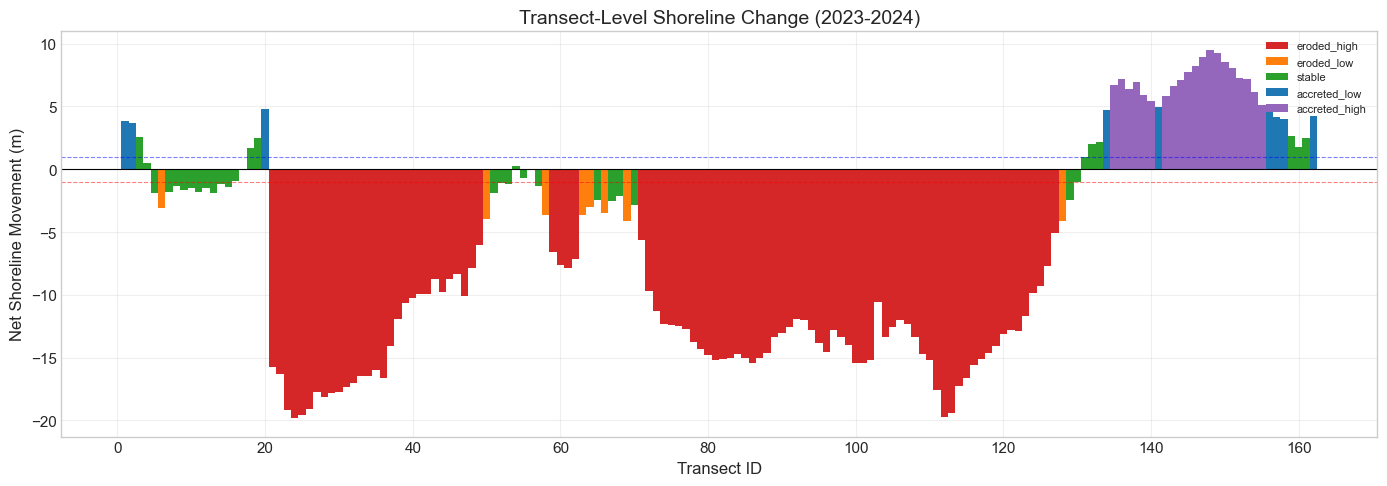

In [6]:
# =============================================================================
# Section 1.2 — Spatial profile plot (latest shoreline interval)
# =============================================================================

color_map = {
    'eroded_high': '#d62728', 'eroded_low': '#ff7f0e',
    'stable': '#2ca02c', 'accreted_low': '#1f77b4', 'accreted_high': '#9467bd'
}

plot_df = latest_dsas_df.copy().sort_values('id')

fig, ax = plt.subplots(figsize=(14, 5))
for cls, clr in color_map.items():
    mask = plot_df['epr_class'] == cls
    ax.bar(
        plot_df.loc[mask, 'id'],
        plot_df.loc[mask, 'NSM'],
        color=clr,
        label=cls,
        width=1.0,
        edgecolor='none'
    )

ax.axhline(0, color='black', lw=0.8)
ax.axhline(LOW_EROSION_THRESHOLD, color='red', ls='--', lw=0.8, alpha=0.5)
ax.axhline(LOW_ACCRETION_THRESHOLD, color='blue', ls='--', lw=0.8, alpha=0.5)
ax.set_xlabel('Transect ID')
ax.set_ylabel('Net Shoreline Movement (m)')
ax.set_title(f'Transect-Level Shoreline Change ({latest_interval_label})')
ax.legend(loc='upper right', fontsize=8)
ax.grid(True, alpha=0.3)

print(f"Latest interval plotted: {latest_interval_label}")
plt.tight_layout()
plt.savefig('./figures/transect_profile.png', dpi=150)
plt.show()


## Section 2 — Environmental Forcing Data → Monthly Time Series

Convert the three oceanographic NetCDF datasets into a **uniform monthly table** that the pattern analysis in Section 3 can consume directly.

Each monsoon year (April–March) of monthly data is paired with the corresponding shoreline interval label when building pattern features.

| Dataset | NetCDF Source | Variables | Monthly stats |
|---------|---------------|-----------|---------------|
| **Wave** | Global Ocean Waves Reanalysis | VHM0, VTPK, VMDR, VSDX, VSDY | max, mean |
| **Wind** | Sea Surface Wind & Stress | wind_speed, eastward_wind, northward_wind | max, mean |
| **Current** | Global Ocean Physics Reanalysis | uo, vo, zos | max, mean |

**Output:** `monthly_combined` — one row per calendar month, all three forcing sources merged. This feeds directly into Section 3.


In [7]:
# =============================================================================
# Section 2.1 — Convert Wind NetCDF to Monthly Dataset (Per-Variable)
# =============================================================================

WIND_VARS = ['wind_speed', 'eastward_wind', 'northward_wind']

wind_df = wind_ds[WIND_VARS].to_dataframe().reset_index()
wind_df = wind_df.dropna(subset=['wind_speed'])

def assign_monsoon_year(time):
    """April (Year N) – March (Year N+1) → Monsoon Year N"""
    ts = pd.Timestamp(time)
    return ts.year if ts.month >= 4 else ts.year - 1

wind_df['monsoon_year'] = wind_df['time'].apply(assign_monsoon_year)
wind_df['year_month'] = wind_df['time'].dt.to_period('M')

# ── Monthly Wind Dataset (per-variable max & mean) ──
wind_monthly = wind_df.groupby(['monsoon_year', 'year_month']).agg({
    'wind_speed': ['max', 'mean'],
    'eastward_wind': ['max', 'mean'],
    'northward_wind': ['max', 'mean'],
    'time': 'first',
}).reset_index()
wind_monthly.columns = ['monsoon_year', 'year_month',
                        'wind_speed_max', 'wind_speed_mean',
                        'eastward_wind_max', 'eastward_wind_mean',
                        'northward_wind_max', 'northward_wind_mean',
                        'time']

print("=" * 60)
print("MONTHLY WIND DATASET (Per-Variable)")
print("=" * 60)
print(f"Shape: {wind_monthly.shape}")
print(f"Period: {wind_monthly['year_month'].min()} – {wind_monthly['year_month'].max()}")
print(f"Variables: wind_speed, eastward_wind, northward_wind")
print(f"Features: {[c for c in wind_monthly.columns if c not in ['time', 'monsoon_year', 'year_month']]}")
display(wind_monthly.head(12))

# ── Annual aggregation (per-variable) ──
wind_annual = wind_df.groupby('monsoon_year').agg({
    'wind_speed': ['max', 'mean'],
    'eastward_wind': ['max', 'mean'],
    'northward_wind': ['max', 'mean'],
}).reset_index()
wind_annual.columns = ['monsoon_year',
                       'wind_speed_max_annual', 'wind_speed_mean_annual',
                       'eastward_wind_max_annual', 'eastward_wind_mean_annual',
                       'northward_wind_max_annual', 'northward_wind_mean_annual']

print(f"\nWind monthly: {wind_monthly.shape}  |  Wind annual: {wind_annual.shape}")

MONTHLY WIND DATASET (Per-Variable)
Shape: (175, 9)
Period: 2009-08 – 2024-02
Variables: wind_speed, eastward_wind, northward_wind
Features: ['wind_speed_max', 'wind_speed_mean', 'eastward_wind_max', 'eastward_wind_mean', 'northward_wind_max', 'northward_wind_mean']


,monsoon_year,year_month,wind_speed_max,wind_speed_mean,eastward_wind_max,eastward_wind_mean,northward_wind_max,northward_wind_mean,time
0,2009,2009-08,5.74,5.74,5.29,5.29,0.54,0.54,2009-08-01
1,2009,2009-09,5.73,5.73,5.60,5.60,0.37,0.37,2009-09-01
2,2009,2009-10,3.37,3.37,2.47,2.47,0.00,0.00,2009-10-01
3,2009,2009-11,2.77,2.77,0.20,0.20,0.72,0.72,2009-11-01
4,2009,2009-12,2.47,2.47,-0.21,-0.21,-0.72,-0.72,2009-12-01
5,2009,2010-01,2.22,2.22,0.37,0.37,0.04,0.04,2010-01-01
6,2009,2010-02,2.22,2.22,-0.17,-0.17,0.38,0.38,2010-02-01
7,2009,2010-03,2.38,2.38,0.42,0.42,0.42,0.42,2010-03-01
8,2010,2010-04,2.71,2.71,1.30,1.30,0.44,0.44,2010-04-01
9,2010,2010-05,4.50,4.50,4.12,4.12,0.85,0.85,2010-05-01



Wind monthly: (175, 9)  |  Wind annual: (15, 7)


In [8]:
# =============================================================================
# Section 2.2 — Convert Wave NetCDF to Monthly Dataset (Per-Variable)
# =============================================================================

WAVE_VARS = ['VHM0', 'VTPK', 'VMDR', 'VSDX', 'VSDY']

# Select single nearest longitude point (wave file may have multiple)
wave_sel = wave_ds
if 'longitude' in wave_ds.dims and wave_ds.sizes['longitude'] > 1:
    wave_sel = wave_ds.isel(longitude=0)
    print(f"Selected wave longitude: {float(wave_sel.longitude.values)}")
if 'latitude' in wave_ds.dims and wave_ds.sizes['latitude'] > 1:
    wave_sel = wave_sel.isel(latitude=0)
    print(f"Selected wave latitude: {float(wave_sel.latitude.values)}")

# Auto-detect available variables
available_wave_vars = [v for v in WAVE_VARS if v in wave_sel.data_vars]
missing_wave_vars = [v for v in WAVE_VARS if v not in wave_sel.data_vars]
if missing_wave_vars:
    print(f"⚠ Missing wave variables (will be filled with 0): {missing_wave_vars}")

wave_df = wave_sel[available_wave_vars].to_dataframe().reset_index()
wave_df = wave_df.dropna(subset=['VHM0'])

# Fill missing variables with 0
for mv in missing_wave_vars:
    wave_df[mv] = 0.0

wave_df['monsoon_year'] = wave_df['time'].apply(assign_monsoon_year)
wave_df['year_month'] = wave_df['time'].dt.to_period('M')

print(f"Wave records: {len(wave_df)}")
print(f"Time range: {wave_df['time'].min()} – {wave_df['time'].max()}")
print(f"Available: {available_wave_vars} | Missing: {missing_wave_vars}")

# ── Monthly Wave Dataset (per-variable max & mean) ──
wave_monthly = wave_df.groupby(['monsoon_year', 'year_month']).agg({
    'VHM0': ['max', 'mean'],
    'VTPK': ['max', 'mean'],
    'VMDR': ['mean'],
    'VSDX': ['max', 'mean'],
    'VSDY': ['max', 'mean'],
    'time': 'first',
}).reset_index()
wave_monthly.columns = ['monsoon_year', 'year_month',
                        'VHM0_max', 'VHM0_mean',
                        'VTPK_max', 'VTPK_mean',
                        'VMDR_mean',
                        'VSDX_max', 'VSDX_mean',
                        'VSDY_max', 'VSDY_mean',
                        'time']

print("=" * 60)
print("MONTHLY WAVE DATASET (Per-Variable)")
print("=" * 60)
print(f"Shape: {wave_monthly.shape}")
print(f"Period: {wave_monthly['year_month'].min()} – {wave_monthly['year_month'].max()}")
print(f"Variables: VHM0, VTPK, VMDR, VSDX, VSDY")
print(f"Features: {[c for c in wave_monthly.columns if c not in ['time', 'monsoon_year', 'year_month']]}")
display(wave_monthly.head(12))

# ── Annual aggregation (per-variable) ──
wave_annual = wave_df.groupby('monsoon_year').agg({
    'VHM0': ['max', 'mean'],
    'VTPK': ['max', 'mean'],
    'VMDR': ['mean'],
    'VSDX': ['max', 'mean'],
    'VSDY': ['max', 'mean'],
}).reset_index()
wave_annual.columns = ['monsoon_year',
                       'VHM0_max_annual', 'VHM0_mean_annual',
                       'VTPK_max_annual', 'VTPK_mean_annual',
                       'VMDR_mean_annual',
                       'VSDX_max_annual', 'VSDX_mean_annual',
                       'VSDY_max_annual', 'VSDY_mean_annual']

print(f"\nWave monthly: {wave_monthly.shape}  |  Wave annual: {wave_annual.shape}")

Selected wave longitude: 79.79998779296875
Wave records: 42601
Time range: 2009-08-01 21:00:00 – 2024-02-29 21:00:00
Available: ['VHM0', 'VTPK', 'VMDR', 'VSDX', 'VSDY'] | Missing: []
MONTHLY WAVE DATASET (Per-Variable)
Shape: (175, 12)
Period: 2009-08 – 2024-02
Variables: VHM0, VTPK, VMDR, VSDX, VSDY
Features: ['VHM0_max', 'VHM0_mean', 'VTPK_max', 'VTPK_mean', 'VMDR_mean', 'VSDX_max', 'VSDX_mean', 'VSDY_max', 'VSDY_mean']


,monsoon_year,year_month,VHM0_max,VHM0_mean,VTPK_max,VTPK_mean,VMDR_mean,VSDX_max,VSDX_mean,VSDY_max,VSDY_mean,time
0,2009,2009-08,2.66,2.153361,18.070000,12.907843,212.241241,0.14,0.087967,0.08,0.027635,2009-08-01 21:00:00
1,2009,2009-09,3.05,2.066542,20.100000,12.748209,210.411911,0.14,0.089792,0.06,0.028208,2009-09-01 00:00:00
2,2009,2009-10,2.99,1.594597,19.170000,12.855283,187.024841,0.16,0.030968,0.07,0.012419,2009-10-01 00:00:00
3,2009,2009-11,2.20,1.258333,17.059999,11.808750,189.738297,0.11,0.013708,0.09,0.010208,2009-11-01 00:00:00
4,2009,2009-12,1.81,1.147984,17.480000,10.599839,199.178635,0.06,0.003508,0.02,-0.018790,2009-12-01 00:00:00
5,2009,2010-01,1.53,1.127460,17.420000,12.571856,198.270111,0.04,0.002581,0.03,-0.017056,2010-01-01 00:00:00
6,2009,2010-02,1.55,1.036384,20.870001,13.007365,202.815628,0.02,-0.002545,0.02,-0.006071,2010-02-01 00:00:00
7,2009,2010-03,1.50,1.163427,21.660000,13.861976,179.948456,0.07,-0.000605,0.04,0.004758,2010-03-01 00:00:00
8,2010,2010-04,2.06,1.383292,18.879999,12.955708,181.481995,0.07,0.016125,0.05,0.013958,2010-04-01 00:00:00
9,2010,2010-05,2.53,1.820847,19.400000,12.238912,202.733093,0.13,0.064718,0.09,0.031774,2010-05-01 00:00:00



Wave monthly: (175, 12)  |  Wave annual: (15, 10)


In [9]:
# =============================================================================
# Section 2.3 — Convert Current NetCDF to Monthly Dataset (Per-Variable)
# =============================================================================

CURRENT_VARS = ['uo', 'vo', 'zos']

# Select surface depth (index 0) for uo, vo
if 'depth' in current_ds.dims:
    current_surface = current_ds.isel(depth=0)
else:
    current_surface = current_ds

current_df = current_surface[CURRENT_VARS].to_dataframe().reset_index()
current_df = current_df.dropna(subset=['uo'])
current_df['monsoon_year'] = current_df['time'].apply(assign_monsoon_year)
current_df['year_month'] = current_df['time'].dt.to_period('M')

# ── Monthly Current Dataset (per-variable max & mean) ──
current_monthly = current_df.groupby(['monsoon_year', 'year_month']).agg({
    'uo': ['max', 'mean'],
    'vo': ['max', 'mean'],
    'zos': ['max', 'mean'],
    'time': 'first',
}).reset_index()
current_monthly.columns = ['monsoon_year', 'year_month',
                           'uo_max', 'uo_mean',
                           'vo_max', 'vo_mean',
                           'zos_max', 'zos_mean', 'time']

print("=" * 60)
print("MONTHLY CURRENT DATASET (Per-Variable)")
print("=" * 60)
print(f"Shape: {current_monthly.shape}")
print(f"Period: {current_monthly['year_month'].min()} – {current_monthly['year_month'].max()}")
print(f"Variables: uo, vo, zos")
print(f"Features: {[c for c in current_monthly.columns if c not in ['time', 'monsoon_year', 'year_month']]}")
display(current_monthly.head(12))

# ── Annual aggregation (per-variable) ──
current_annual = current_df.groupby('monsoon_year').agg({
    'uo': ['max', 'mean'],
    'vo': ['max', 'mean'],
    'zos': ['max', 'mean'],
}).reset_index()
current_annual.columns = ['monsoon_year',
                          'uo_max_annual', 'uo_mean_annual',
                          'vo_max_annual', 'vo_mean_annual',
                          'zos_max_annual', 'zos_mean_annual']

print(f"\nCurrent monthly: {current_monthly.shape}  |  Current annual: {current_annual.shape}")

MONTHLY CURRENT DATASET (Per-Variable)
Shape: (175, 9)
Period: 2009-08 – 2024-02
Variables: uo, vo, zos
Features: ['uo_max', 'uo_mean', 'vo_max', 'vo_mean', 'zos_max', 'zos_mean']


,monsoon_year,year_month,uo_max,uo_mean,vo_max,vo_mean,zos_max,zos_mean,time
0,2009,2009-08,0.264901,0.264901,-0.178228,-0.178228,0.312815,0.312815,2009-08-01
1,2009,2009-09,0.342418,0.342418,-0.239265,-0.239265,0.357982,0.357982,2009-09-01
2,2009,2009-10,-0.082400,-0.082400,0.035401,0.035401,0.386059,0.386059,2009-10-01
3,2009,2009-11,-0.272835,-0.272835,0.130619,0.130619,0.463576,0.463576,2009-11-01
4,2009,2009-12,-0.236824,-0.236824,0.031129,0.031129,0.523087,0.523087,2009-12-01
5,2009,2010-01,-0.208136,-0.208136,-0.003052,-0.003052,0.515152,0.515152,2010-01-01
6,2009,2010-02,-0.184942,-0.184942,0.067141,0.067141,0.513016,0.513016,2010-02-01
7,2009,2010-03,-0.147710,-0.147710,0.058596,0.058596,0.482803,0.482803,2010-03-01
8,2010,2010-04,-0.020753,-0.020753,0.009156,0.009156,0.432142,0.432142,2010-04-01
9,2010,2010-05,0.151982,0.151982,-0.134892,-0.134892,0.467544,0.467544,2010-05-01



Current monthly: (175, 9)  |  Current annual: (15, 7)


### Section 2.4 — Merge into Unified Monthly Forcing Table (`monthly_combined`)

Wave, Wind, and Current monthly datasets are joined on `monsoon_year` and `year_month` into a single table.

Each row = one calendar month. `year_month` is the primary time index.

> **`monthly_combined` is the key input for the pattern feature extraction in Section 3.**


In [10]:
# =============================================================================
# Section 2.4 — Display monthly datasets
# =============================================================================

# Merge into one combined monthly dataset
monthly_combined = wave_monthly.merge(
    wind_monthly, on=['monsoon_year', 'year_month'], how='outer', suffixes=('_wave', '_wind')
)
monthly_combined = monthly_combined.merge(
    current_monthly, on=['monsoon_year', 'year_month'], how='outer'
)
monthly_combined = monthly_combined.sort_values('year_month').reset_index(drop=True)

print("=" * 60)
print("MONTHLY DATASET SUMMARY")
print("=" * 60)
print(f"  Wave monthly  : {wave_monthly.shape[0]} months × {wave_monthly.shape[1] - 2} features")
print(f"  Wind monthly  : {wind_monthly.shape[0]} months × {wind_monthly.shape[1] - 2} features")
print(f"  Current monthly: {current_monthly.shape[0]} months × {current_monthly.shape[1] - 2} features")
print(f"  Combined monthly: {monthly_combined.shape}")

print(f"\n{'='*60}")
print("COMBINED MONTHLY FORCING (first 12 months)")
print("=" * 60)
display(monthly_combined.head(12))

MONTHLY DATASET SUMMARY
  Wave monthly  : 175 months × 10 features
  Wind monthly  : 175 months × 7 features
  Current monthly: 175 months × 7 features
  Combined monthly: (175, 26)

COMBINED MONTHLY FORCING (first 12 months)


,monsoon_year,year_month,VHM0_max,VHM0_mean,VTPK_max,VTPK_mean,VMDR_mean,VSDX_max,VSDX_mean,VSDY_max,...,northward_wind_max,northward_wind_mean,time_wind,uo_max,uo_mean,vo_max,vo_mean,zos_max,zos_mean,time
0,2009,2009-08,2.66,2.153361,18.070000,12.907843,212.241241,0.14,0.087967,0.08,...,0.54,0.54,2009-08-01,0.264901,0.264901,-0.178228,-0.178228,0.312815,0.312815,2009-08-01
1,2009,2009-09,3.05,2.066542,20.100000,12.748209,210.411911,0.14,0.089792,0.06,...,0.37,0.37,2009-09-01,0.342418,0.342418,-0.239265,-0.239265,0.357982,0.357982,2009-09-01
2,2009,2009-10,2.99,1.594597,19.170000,12.855283,187.024841,0.16,0.030968,0.07,...,0.00,0.00,2009-10-01,-0.082400,-0.082400,0.035401,0.035401,0.386059,0.386059,2009-10-01
3,2009,2009-11,2.20,1.258333,17.059999,11.808750,189.738297,0.11,0.013708,0.09,...,0.72,0.72,2009-11-01,-0.272835,-0.272835,0.130619,0.130619,0.463576,0.463576,2009-11-01
4,2009,2009-12,1.81,1.147984,17.480000,10.599839,199.178635,0.06,0.003508,0.02,...,-0.72,-0.72,2009-12-01,-0.236824,-0.236824,0.031129,0.031129,0.523087,0.523087,2009-12-01
5,2009,2010-01,1.53,1.127460,17.420000,12.571856,198.270111,0.04,0.002581,0.03,...,0.04,0.04,2010-01-01,-0.208136,-0.208136,-0.003052,-0.003052,0.515152,0.515152,2010-01-01
6,2009,2010-02,1.55,1.036384,20.870001,13.007365,202.815628,0.02,-0.002545,0.02,...,0.38,0.38,2010-02-01,-0.184942,-0.184942,0.067141,0.067141,0.513016,0.513016,2010-02-01
7,2009,2010-03,1.50,1.163427,21.660000,13.861976,179.948456,0.07,-0.000605,0.04,...,0.42,0.42,2010-03-01,-0.147710,-0.147710,0.058596,0.058596,0.482803,0.482803,2010-03-01
8,2010,2010-04,2.06,1.383292,18.879999,12.955708,181.481995,0.07,0.016125,0.05,...,0.44,0.44,2010-04-01,-0.020753,-0.020753,0.009156,0.009156,0.432142,0.432142,2010-04-01
9,2010,2010-05,2.53,1.820847,19.400000,12.238912,202.733093,0.13,0.064718,0.09,...,0.85,0.85,2010-05-01,0.151982,0.151982,-0.134892,-0.134892,0.467544,0.467544,2010-05-01


## Section 3 — Five-Class Monthly Threshold Workflow

**This is the core research analysis.** Using the full five-class shoreline labels and monthly pattern signatures extracted from the wave, wind, and current forcing data.

Steps:

1. Uses the shoreline CSV **file name year** as the authoritative shoreline interval key.
2. Keeps the shoreline target in the full **five-class** form: `eroded_high`, `eroded_low`, `stable`, `accreted_low`, `accreted_high`.
3. Learns **monthly pattern signatures** (anomaly-based features: percentiles, slopes, anomaly runs) inside each monsoon-year interval (full April–March window).
4. Estimates **four boundary thresholds per driver**: `severe_erosion`, `erosion_onset`, `accretion_onset`, `strong_accretion` — forming the threshold range for each coastal driver.
5. Forecasts **future threshold ranges directly from historical threshold trajectories** using TheilSen regression — 24 months ahead at H6, H12, H18, H24 horizons.

**If a shoreline class is absent in the historical record**, the notebook keeps that class in the ordered framework but reports its threshold as structurally unsupported rather than inventing values.


In [11]:
# =============================================================================
# Section 3.1 — Monthly Pattern Feature Extraction per Shoreline Interval
# =============================================================================
# For each monsoon year (April–March), extract anomaly-based pattern features
# from the monthly wave, wind, and current forcing data.
#
# Instead of simple annual max/mean values, we capture WHEN and HOW OFTEN
# forcing was abnormal within each 12-month shoreline interval.
# This preserves the seasonal monsoon structure of the Sri Lanka coast.
#
# Features computed per forcing variable per interval (14 per variable):
#   __p10, __p50, __p90, __iqr       — distribution shape within the year
#   __anom_mean                       — mean standardised anomaly vs climatology
#   __anom_peak_pos, __anom_peak_neg  — max positive / negative anomaly (σ)
#   __anom_abs_sum                    — total absolute anomaly load
#   __anom_pos_months, __run_pos      — count & longest run of +1σ months
#   __anom_neg_months, __run_neg      — count & longest run of −1σ months
#   __late_minus_early                — 2nd-half vs 1st-half seasonal difference
#   __slope                           — linear trend across the interval
#
# Output: pattern_df — one row per monsoon year, all pattern features + class label
# =============================================================================

# Ordered class labels and code mappings (codes 0–4 map to eroded_high → accreted_high)
FIVE_CLASS_ORDER = ['eroded_high', 'eroded_low', 'stable', 'accreted_low', 'accreted_high']
CLASS_TO_CODE = {label: idx for idx, label in enumerate(FIVE_CLASS_ORDER)}
CODE_TO_CLASS = {idx: label for label, idx in CLASS_TO_CODE.items()}

MIN_INTERVAL_MONTHS = 8   # skip any interval with fewer months of forcing data
SEASON_SPLIT_MONTHS = 6   # split window for late_minus_early feature


def longest_run(mask):
    """Count the longest consecutive True run in a boolean array."""
    best = 0
    current = 0
    for flag in mask:
        if bool(flag):
            current += 1
            best = max(best, current)
        else:
            current = 0
    return int(best)


# ── Normalise year_month to Timestamp (handles Period input) ──────────────────
monthly_combined = monthly_combined.copy()
year_month_series = monthly_combined['year_month']
if pd.api.types.is_period_dtype(year_month_series):
    year_month_series = year_month_series.dt.to_timestamp(how='start')
else:
    year_month_series = pd.to_datetime(year_month_series).dt.to_period('M').dt.to_timestamp()
monthly_combined['year_month'] = year_month_series
monthly_combined = monthly_combined.sort_values('year_month').reset_index(drop=True)

# ── Attach ordered class codes to shoreline_annual ────────────────────────────
shoreline_annual = shoreline_annual.copy()
shoreline_annual['Change_Class'] = pd.Categorical(
    shoreline_annual['Change_Class'],
    categories=FIVE_CLASS_ORDER,
    ordered=True,
)
shoreline_annual['class_code'] = shoreline_annual['Change_Class'].map(CLASS_TO_CODE).astype(int)
shoreline_annual['shoreline_score'] = shoreline_annual['class_code'] - 2   # centred: −2 to +2

# ── Identify numeric forcing columns (excludes year_month, monsoon_year) ──────
monthly_feature_cols = [
    column
    for column in monthly_combined.columns
    if column not in ['monsoon_year', 'year_month']
    and pd.api.types.is_numeric_dtype(monthly_combined[column])
]

# ── Pre-compute monthly climatology (mean, std, q10, q90) per calendar month ──
monthly_climatology = {}
for feature_name in monthly_feature_cols:
    climatology = monthly_combined[['year_month', feature_name]].copy()
    climatology['calendar_month'] = climatology['year_month'].dt.month
    monthly_climatology[feature_name] = (
        climatology.groupby('calendar_month')[feature_name]
        .agg(
            mean='mean',
            std='std',
            q10=lambda series: series.quantile(0.10),
            q90=lambda series: series.quantile(0.90),
        )
        .replace({'std': {0.0: np.nan}})
    )

# ── Feature extraction loop — one iteration per shoreline interval ─────────────
interval_feature_rows = []
interval_month_lookup = {}

for shoreline_row in shoreline_annual.sort_values('year').itertuples(index=False):
    monsoon_year = int(shoreline_row.year)
    window_start = pd.Timestamp(f'{monsoon_year}-04-01')
    window_end   = pd.Timestamp(f'{monsoon_year + 1}-03-01')

    # Slice the 12 forcing months that fall within this April–March interval
    interval_window = monthly_combined[
        monthly_combined['year_month'].between(window_start, window_end)
    ].copy()

    if len(interval_window) < MIN_INTERVAL_MONTHS:
        print(
            f"[SKIPPED] {shoreline_row.interval_label}: only {len(interval_window)} monthly records available"
        )
        continue

    interval_window = interval_window.sort_values('year_month').reset_index(drop=True)
    interval_month_lookup[monsoon_year] = interval_window.copy()

    # Base row: metadata + class label
    feature_row = {
        'monsoon_year':    monsoon_year,
        'interval_label':  shoreline_row.interval_label,
        'n_months':        int(len(interval_window)),
        'Change_Class':    shoreline_row.Change_Class,
        'class_code':      int(shoreline_row.class_code),
        'shoreline_score': int(shoreline_row.shoreline_score),
        'annual_NSM':      float(shoreline_row.annual_NSM),
        'NSM_count':       int(shoreline_row.NSM_count),
    }

    # Compute 14 anomaly-based pattern features per forcing variable
    for feature_name in monthly_feature_cols:
        values = interval_window[feature_name].astype(float).to_numpy()
        if np.all(np.isnan(values)):
            continue

        # Standardised anomalies relative to calendar-month climatology
        calendar_months    = interval_window['year_month'].dt.month.to_numpy()
        climatology        = monthly_climatology[feature_name].reindex(calendar_months)
        climatology_mean   = climatology['mean'].to_numpy(dtype=float)
        climatology_std    = climatology['std'].to_numpy(dtype=float)

        anomalies = np.divide(
            values - climatology_mean,
            climatology_std,
            out=np.zeros_like(values, dtype=float),
            where=np.isfinite(climatology_std) & (climatology_std > 0),
        )
        anomalies = np.where(np.isfinite(anomalies), anomalies, 0.0)

        half_window  = min(SEASON_SPLIT_MONTHS, max(len(values) // 2, 1))
        early_values = values[:half_window]
        late_values  = values[-half_window:]
        time_index   = np.arange(len(values), dtype=float)

        slope = 0.0
        if len(values) >= 2 and np.nanstd(values) > 0:
            slope = float(np.polyfit(time_index, values, 1)[0])

        # Write all 14 features
        feature_row[f'{feature_name}__p10']            = float(np.nanpercentile(values, 10))
        feature_row[f'{feature_name}__p50']            = float(np.nanpercentile(values, 50))
        feature_row[f'{feature_name}__p90']            = float(np.nanpercentile(values, 90))
        feature_row[f'{feature_name}__iqr']            = float(np.nanpercentile(values, 75) - np.nanpercentile(values, 25))
        feature_row[f'{feature_name}__anom_mean']      = float(np.nanmean(anomalies))
        feature_row[f'{feature_name}__anom_peak_pos']  = float(np.nanmax(anomalies))
        feature_row[f'{feature_name}__anom_peak_neg']  = float(np.nanmin(anomalies))
        feature_row[f'{feature_name}__anom_abs_sum']   = float(np.nansum(np.abs(anomalies)))
        feature_row[f'{feature_name}__anom_pos_months'] = int(np.sum(anomalies >= 1.0))
        feature_row[f'{feature_name}__anom_neg_months'] = int(np.sum(anomalies <= -1.0))
        feature_row[f'{feature_name}__run_pos']        = longest_run(anomalies >= 1.0)
        feature_row[f'{feature_name}__run_neg']        = longest_run(anomalies <= -1.0)
        feature_row[f'{feature_name}__late_minus_early'] = float(np.nanmean(late_values) - np.nanmean(early_values))
        feature_row[f'{feature_name}__slope']          = slope

    interval_feature_rows.append(feature_row)

# pattern_df: one row per monsoon year — used in all downstream sections
analysis_df = pd.DataFrame(interval_feature_rows).sort_values('monsoon_year').reset_index(drop=True)
pattern_df  = analysis_df.copy()

print('=== FIVE-CLASS MONTHLY PATTERN DATASET ===')
print(f'Intervals retained : {len(pattern_df)} / {len(shoreline_annual)}')
print(f'Monthly forcing cols: {len(monthly_feature_cols)}')
print(f'Pattern feature cols: {pattern_df.shape[1] - 8}')
print('\nClass counts:')
print(pattern_df['Change_Class'].value_counts().reindex(FIVE_CLASS_ORDER, fill_value=0).to_string())
print('\nInterval coverage:')
print(pattern_df[['monsoon_year', 'interval_label', 'n_months', 'Change_Class', 'annual_NSM']].to_string(index=False))


=== FIVE-CLASS MONTHLY PATTERN DATASET ===
Intervals retained : 12 / 12
Monthly forcing cols: 21
Pattern feature cols: 294

Class counts:
Change_Class
eroded_high      4
eroded_low       2
stable           3
accreted_low     2
accreted_high    1

Interval coverage:
 monsoon_year interval_label  n_months  Change_Class  annual_NSM
         2012      2012-2013        12    eroded_low   -2.677923
         2013      2013-2014        12   eroded_high   -6.502348
         2014      2014-2015        12 accreted_high    4.247188
         2015      2015-2016        12    eroded_low   -3.300930
         2016      2016-2017        12  accreted_low    3.720458
         2017      2017-2018        12  accreted_low    1.870692
         2018      2018-2019        12   eroded_high   -4.807674
         2019      2019-2020        12   eroded_high   -3.760938
         2020      2020-2021        12        stable    1.629167
         2021      2021-2022        12        stable    1.731679
         2022      

In [ ]:
# =============================================================================
# Section 3.2 — Five-Class Pattern Recognition  ·  LOOCV Ensemble + SHAP
# =============================================================================
# TECHNIQUE OVERVIEW
# ──────────────────
# With only 12 annual observations, every classical train/test split wastes
# data.  Leave-One-Out Cross-Validation (LOOCV) is the statistically correct
# choice: train on 11 years, test on the left-out year, repeat 12 times.
#
# Ensemble (three diverse base models):
#   1. Multinomial Logistic Regression   — linear decision boundary, fast
#   2. Gradient Boosting Classifier      — non-linear, handles class imbalance
#   3. Random Forest (isotonic-calibrated) — tree ensemble, well-calibrated
#      probabilities via CalibratedClassifierCV (isotonic regression)
#
# Final class = argmax of probability-averaged ensemble.
#
# Post-LOOCV model quality metrics:
#   • Balanced accuracy  — accounts for class imbalance
#   • Macro F1           — equal weight to each class
#   • Multi-class ROC AUC (one-vs-rest, macro average)
#   • Confusion matrix
#
# Interpretability:
#   • SHAP TreeExplainer on the full-data RF — mean |SHAP| per feature
#   • Permutation importance (5-fold, balanced) to cross-validate RF
# =============================================================================

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import roc_auc_score
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import label_binarize
import shap

PATTERN_META_COLS = [
    'monsoon_year', 'interval_label', 'n_months',
    'Change_Class', 'class_code', 'shoreline_score',
    'annual_NSM', 'NSM_count',
]
MAX_FEATURES_PER_DRIVER = 2
MAX_SELECTED_FEATURES   = 14

pattern_feature_cols = [col for col in pattern_df.columns if col not in PATTERN_META_COLS]
present_class_codes  = sorted(pattern_df['class_code'].unique())
present_class_labels = [CODE_TO_CLASS[code] for code in present_class_codes]

# ── Step 1: Feature screening (Spearman + KW + MI composite) ─────────────────
feature_screening_rows = []

mi_input = pattern_df[pattern_feature_cols].copy()
mi_input = mi_input.replace([np.inf, -np.inf], np.nan).fillna(mi_input.median(numeric_only=True))
mi_scores = mutual_info_classif(mi_input, pattern_df['class_code'], random_state=42, discrete_features=False)
mi_lookup = dict(zip(pattern_feature_cols, mi_scores))

for feature_name in pattern_feature_cols:
    feature_values = pattern_df[feature_name].astype(float)
    valid_mask = feature_values.notna()
    if valid_mask.sum() < 6 or feature_values.nunique(dropna=True) < 3:
        continue
    rho, rho_p = spearmanr(feature_values[valid_mask], pattern_df.loc[valid_mask, 'shoreline_score'], nan_policy='omit')
    if not np.isfinite(rho):
        rho, rho_p = 0.0, 1.0
    class_groups = [
        pattern_df.loc[pattern_df['Change_Class'] == cls, feature_name].dropna().values
        for cls in present_class_labels
        if pattern_df.loc[pattern_df['Change_Class'] == cls, feature_name].dropna().size > 0
    ]
    kw_stat, kw_p = kruskal(*class_groups) if len(class_groups) >= 2 else (np.nan, 1.0)
    composite_score = (
        2.0 * abs(float(rho))
        + float(mi_lookup.get(feature_name, 0.0))
        + max(0.0, -np.log10(float(kw_p) + 1e-12))
    )
    feature_screening_rows.append({
        'feature': feature_name, 'driver': feature_name.split('__')[0],
        'spearman_rho': float(rho), 'spearman_p': float(rho_p) if np.isfinite(rho_p) else 1.0,
        'kruskal_h': float(kw_stat) if np.isfinite(kw_stat) else np.nan,
        'kruskal_p': float(kw_p) if np.isfinite(kw_p) else 1.0,
        'mutual_info': float(mi_lookup.get(feature_name, 0.0)),
        'composite_score': float(composite_score),
    })

screening_df = (
    pd.DataFrame(feature_screening_rows)
    .sort_values(['composite_score', 'mutual_info', 'kruskal_h'], ascending=[False, False, False])
    .reset_index(drop=True)
)

# Select top 2 per driver, up to MAX_SELECTED_FEATURES
selected_features, driver_feature_counts = [], {}
for screening_row in screening_df.itertuples(index=False):
    d = screening_row.driver
    if driver_feature_counts.get(d, 0) >= MAX_FEATURES_PER_DRIVER:
        continue
    selected_features.append(screening_row.feature)
    driver_feature_counts[d] = driver_feature_counts.get(d, 0) + 1
    if len(selected_features) >= min(MAX_SELECTED_FEATURES, len(screening_df)):
        break
if len(selected_features) < 6:
    selected_features = screening_df.head(min(6, len(screening_df)))['feature'].tolist()

feature_matrix = pattern_df[selected_features].replace([np.inf, -np.inf], np.nan)
feature_matrix = feature_matrix.fillna(feature_matrix.median(numeric_only=True))
X_pattern = feature_matrix.to_numpy(dtype=float)
y_pattern  = pattern_df['class_code'].to_numpy(dtype=int)

confusion_labels = present_class_codes
confusion_names  = [CODE_TO_CLASS[code] for code in confusion_labels]

# ── Step 2: LOOCV with 3-model ensemble ──────────────────────────────────────
loo      = LeaveOneOut()
loo_rows = []
all_loo_proba = np.zeros((len(X_pattern), len(FIVE_CLASS_ORDER)), dtype=float)


def aligned_probabilities(model, x_test, five_class_order=FIVE_CLASS_ORDER):
    prob = np.zeros(len(five_class_order), dtype=float)
    if hasattr(model, 'predict_proba'):
        raw = model.predict_proba(x_test)[0]
        for code, p in zip(model.classes_, raw):
            prob[int(code)] = float(p)
    else:
        prob[int(model.predict(x_test)[0])] = 1.0
    return prob


for train_idx, test_idx in loo.split(X_pattern):
    X_tr, X_te = X_pattern[train_idx], X_pattern[test_idx]
    y_tr, y_te = y_pattern[train_idx], y_pattern[test_idx]
    probs = []

    # Model A: Multinomial Logistic Regression (L2 regularised, balanced)
    logit = Pipeline([
        ('sc', StandardScaler()),
        ('m', LogisticRegression(class_weight='balanced', solver='lbfgs', max_iter=4000, C=0.75, random_state=42)),
    ])
    try:
        logit.fit(X_tr, y_tr)
        probs.append(aligned_probabilities(logit, X_te))
    except Exception:
        pass

    # Model B: Gradient Boosting Classifier (50 weak learners, shallow)
    # Handles non-linear boundaries and class imbalance via sample_weight
    gb = GradientBoostingClassifier(
        n_estimators=50, max_depth=2, learning_rate=0.15, subsample=0.8,
        min_samples_leaf=1, random_state=42,
    )
    sw = np.array([1.0 / max((y_tr == c).sum(), 1) for c in y_tr], dtype=float)
    sw /= sw.mean()
    try:
        gb.fit(X_tr, y_tr, sample_weight=sw)
        probs.append(aligned_probabilities(gb, X_te))
    except Exception:
        pass

    # Model C: Random Forest with isotonic probability calibration (CalibratedClassifierCV)
    # Isotonic calibration corrects the known RF probability over-confidence bias.
    rf_base = RandomForestClassifier(
        n_estimators=500, max_depth=4, min_samples_leaf=1,
        class_weight='balanced_subsample', random_state=42,
    )
    rf_cal = CalibratedClassifierCV(rf_base, method='isotonic', cv=min(3, len(y_tr) // 3))
    try:
        rf_cal.fit(X_tr, y_tr)
        probs.append(aligned_probabilities(rf_cal, X_te))
    except Exception:
        try:
            rf_base.fit(X_tr, y_tr)
            probs.append(aligned_probabilities(rf_base, X_te))
        except Exception:
            pass

    if not probs:
        fallback = np.zeros(len(FIVE_CLASS_ORDER), dtype=float)
        fallback[int(pd.Series(y_tr).mode().iloc[0])] = 1.0
        probs.append(fallback)

    mean_prob = np.mean(probs, axis=0)
    all_loo_proba[test_idx[0]] = mean_prob
    pred = int(np.argmax(mean_prob))
    loo_rows.append({
        'monsoon_year':    int(pattern_df.iloc[test_idx[0]]['monsoon_year']),
        'actual_code':     int(y_te[0]),
        'predicted_code':  pred,
        'actual_class':    CODE_TO_CLASS[int(y_te[0])],
        'predicted_class': CODE_TO_CLASS[pred],
        'correct':         bool(pred == int(y_te[0])),
        'top_probability': float(mean_prob[pred]),
    })

pattern_skill_df = pd.DataFrame(loo_rows).sort_values('monsoon_year').reset_index(drop=True)
pattern_balanced_accuracy = balanced_accuracy_score(
    pattern_skill_df['actual_code'], pattern_skill_df['predicted_code'],
)
pattern_macro_f1 = f1_score(
    pattern_skill_df['actual_code'], pattern_skill_df['predicted_code'],
    average='macro', labels=confusion_labels,
)
pattern_confusion = confusion_matrix(
    pattern_skill_df['actual_code'], pattern_skill_df['predicted_code'],
    labels=confusion_labels,
)

# Multi-class ROC AUC (one-vs-rest) — reflects per-class discrimination ability
try:
    y_bin = label_binarize(y_pattern, classes=list(range(len(FIVE_CLASS_ORDER))))
    present_cols = [i for i in present_class_codes]
    loo_proba_present = all_loo_proba[:, present_cols]
    y_bin_present = y_bin[:, present_cols]
    if y_bin_present.shape[1] >= 2 and loo_proba_present.shape[1] >= 2:
        pattern_roc_auc_ovr = roc_auc_score(y_bin_present, loo_proba_present, multi_class='ovr', average='macro')
    else:
        pattern_roc_auc_ovr = np.nan
except Exception:
    pattern_roc_auc_ovr = np.nan

# ── Step 3: Refit full models on all data ─────────────────────────────────────
full_logit = Pipeline([
    ('sc', StandardScaler()),
    ('m', LogisticRegression(class_weight='balanced', solver='lbfgs', max_iter=4000, C=0.75, random_state=42)),
])
full_logit.fit(X_pattern, y_pattern)

full_gb = GradientBoostingClassifier(
    n_estimators=50, max_depth=2, learning_rate=0.15, subsample=0.8,
    min_samples_leaf=1, random_state=42,
)
sw_full = np.array([1.0 / max((y_pattern == c).sum(), 1) for c in y_pattern], dtype=float)
sw_full /= sw_full.mean()
full_gb.fit(X_pattern, y_pattern, sample_weight=sw_full)

full_rf = RandomForestClassifier(
    n_estimators=500, max_depth=4, min_samples_leaf=1,
    class_weight='balanced_subsample', random_state=42,
)
full_rf.fit(X_pattern, y_pattern)

pattern_models = {
    'multinomial_logit':     full_logit,
    'gradient_boosting':     full_gb,
    'random_forest':         full_rf,
}

# ── Step 4: SHAP (TreeSHAP on full RF) ───────────────────────────────────────
# SHAP values give a game-theoretically grounded attribution per feature.
try:
    shap_explainer = shap.TreeExplainer(full_rf)
    shap_values    = shap_explainer.shap_values(X_pattern)   # list of [n_samples, n_features] per class
    # Mean absolute SHAP per feature (averaged across all classes)
    if isinstance(shap_values, list):
        shap_mean_abs = np.mean([np.abs(sv) for sv in shap_values], axis=0).mean(axis=0)
    else:
        shap_mean_abs = np.abs(shap_values).mean(axis=0)
    shap_df = pd.DataFrame({
        'feature':      selected_features,
        'mean_abs_shap': shap_mean_abs,
    }).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)
except Exception as e:
    print(f"[SHAP] Skipped: {e}")
    shap_df = pd.DataFrame({'feature': selected_features, 'mean_abs_shap': np.zeros(len(selected_features))})

# ── Step 5: Permutation importance on full RF ─────────────────────────────────
try:
    perm_result = permutation_importance(
        full_rf, X_pattern, y_pattern,
        n_repeats=30, random_state=42, scoring='balanced_accuracy',
    )
    perm_df = pd.DataFrame({
        'feature':   selected_features,
        'perm_imp_mean': perm_result.importances_mean,
        'perm_imp_std':  perm_result.importances_std,
    }).sort_values('perm_imp_mean', ascending=False).reset_index(drop=True)
except Exception as e:
    print(f"[Permutation importance] Skipped: {e}")
    perm_df = pd.DataFrame({'feature': selected_features, 'perm_imp_mean': np.zeros(len(selected_features)), 'perm_imp_std': np.zeros(len(selected_features))})


def predict_pattern_probabilities(feature_frame):
    """Ensemble probability prediction for new data rows."""
    ff = feature_frame[selected_features].replace([np.inf, -np.inf], np.nan)
    ff = ff.fillna(feature_matrix.median(numeric_only=True)).to_numpy(dtype=float)
    plist = []
    for model in pattern_models.values():
        if hasattr(model, 'predict_proba'):
            raw = model.predict_proba(ff)
            for i, row_p in enumerate(raw):
                aligned = np.zeros(len(FIVE_CLASS_ORDER), dtype=float)
                for code, p in zip(model.classes_, row_p):
                    aligned[int(code)] = float(p)
                if len(plist) <= i:
                    plist.append([aligned])
                else:
                    plist[i].append(aligned)
    return np.array([np.mean(ps, axis=0) for ps in plist])

significant_features = selected_features.copy()

print('=== FIVE-CLASS FEATURE SCREENING ===')
print(f'Present classes: {present_class_labels}')
if 'accreted_high' not in present_class_labels:
    print('NOTE: accreted_high absent from training data — tracked structurally, not trained directly.')
print(f'\nTop screened features:')
print(screening_df.head(20).to_string(index=False))

print('\n=== LOOCV RESULTS (3-Model Ensemble: Logit + GradientBoosting + RF) ===')
print(pattern_skill_df.to_string(index=False))
print(f'\nBalanced accuracy  : {pattern_balanced_accuracy:.3f}')
print(f'Macro F1           : {pattern_macro_f1:.3f}')
print(f'Multi-class ROC AUC (OvR, macro): {pattern_roc_auc_ovr:.3f}' if np.isfinite(pattern_roc_auc_ovr) else 'Multi-class ROC AUC (OvR): N/A')
print('\nConfusion matrix (rows=actual, cols=predicted):')
print(pd.DataFrame(pattern_confusion, index=confusion_names, columns=confusion_names).to_string())

print('\n=== SHAP FEATURE IMPORTANCE (TreeSHAP on full RF) ===')
print(shap_df.to_string(index=False))

print('\n=== PERMUTATION IMPORTANCE (balanced accuracy, 30 repeats) ===')
print(perm_df.to_string(index=False))


=== FIVE-CLASS FEATURE SCREENING ===
Available target classes: ['eroded_high', 'eroded_low', 'stable', 'accreted_low', 'accreted_high']

Top screened features:
                             feature              driver  spearman_rho  spearman_p  kruskal_h  kruskal_p  mutual_info  composite_score
            VSDY_mean__anom_peak_pos           VSDY_mean     -0.903252    0.000057   9.756410   0.044737     0.687193         3.843030
                  VSDY_mean__run_pos           VSDY_mean     -0.857517    0.000362   8.369241   0.078951     0.552381         3.370056
             VSDY_mean__anom_abs_sum           VSDY_mean     -0.852871    0.000422   8.679487   0.069630     0.435029         3.297978
        northward_wind_mean__run_pos northward_wind_mean     -0.793057    0.002087   7.766602   0.100512     0.534307         3.118203
                wind_speed_mean__p50     wind_speed_mean      0.662145    0.018983   8.852564   0.064892     0.508045         3.020142
                      VMDR_mea

In [ ]:
# =============================================================================
# Section 3.3 — Ordered Five-Class Threshold Range Estimation
#               (Ordered Logit  +  KDE Crossings  +  BCa Bootstrap)
# =============================================================================
# TECHNIQUE OVERVIEW
# ──────────────────
# Four boundaries separate the five shoreline classes:
#   severe_erosion   | eroded_high  ↔  eroded_low
#   erosion_onset    | eroded_low   ↔  stable
#   accretion_onset  | stable       ↔  accreted_low
#   strong_accretion | accreted_low ↔  accreted_high
#
# PRIMARY METHOD — Ordered Logit (OrderedModel, statsmodels):
#   • Fits a single latent-variable model respecting the class ORDER
#   • Threshold = grid point where adjacent cumulative probabilities cross
#
# SECONDARY METHOD — KDE Boundary Crossing (scipy.stats.gaussian_kde):
#   • Fit a Gaussian kernel density per class (Scott bandwidth rule)
#   • Threshold = grid point where the two adjacent KDE curves intersect
#   • More data-adaptive; works when classes have non-Gaussian shapes
#
# FINAL ESTIMATE — Ensemble average of logit + KDE thresholds
#   • Reduces method-specific bias; gives a robust point estimate
#
# UNCERTAINTY — Bias-Corrected & Accelerated (BCa) Bootstrap:
#   • Corrects asymmetry and leverage in small-sample bootstrap
#   • Jackknife influence function estimates the acceleration factor
#   • 150 resamples → 95% BCa CI on each boundary
#
# POST-PROCESSING — Isotonic regression enforces strict monotonicity:
#   severe_erosion < erosion_onset < accretion_onset < strong_accretion
#   (prevents logit numerical artefacts from producing crossed thresholds)
#
# CLASS SEPARABILITY — Jensen-Shannon Divergence (JSD):
#   • JSD ∈ [0, 1]; higher = classes are well separated in feature space
#   • Computed for every adjacent class pair per feature
# =============================================================================

from scipy.stats import gaussian_kde, norm as _norm
from sklearn.isotonic import IsotonicRegression

BOUNDARY_NAMES = {
    (0, 1): 'severe_erosion',
    (1, 2): 'erosion_onset',
    (2, 3): 'accretion_onset',
    (3, 4): 'strong_accretion',
}
N_THRESHOLD_BOOT = 150
GRID_SIZE        = 600

screening_lookup = screening_df.set_index('feature').to_dict(orient='index')


# ── Helpers ───────────────────────────────────────────────────────────────────

def _jsd(p, q):
    """Jensen-Shannon divergence (0–1 scale) between two probability arrays."""
    p, q = np.asarray(p, dtype=float) + 1e-12, np.asarray(q, dtype=float) + 1e-12
    p /= p.sum();  q /= q.sum()
    m = 0.5 * (p + q)
    return float(0.5 * np.sum(p * np.log(p / m)) + 0.5 * np.sum(q * np.log(q / m)))


def kde_boundary(values_a, values_b, n_grid=GRID_SIZE):
    """Estimate threshold between class A and class B via KDE intersection."""
    if len(values_a) < 3 or len(values_b) < 3:
        return None, np.nan
    combined = np.concatenate([values_a, values_b])
    span     = combined.std() * 2.5
    grid     = np.linspace(combined.min() - span, combined.max() + span, n_grid)
    try:
        kde_a = gaussian_kde(values_a, bw_method='scott')
        kde_b = gaussian_kde(values_b, bw_method='scott')
    except Exception:
        return None, np.nan
    fa, fb = kde_a(grid), kde_b(grid)
    diff   = fa - fb
    crosses = np.where(np.diff(np.sign(diff)))[0]
    mid    = (np.median(values_a) + np.median(values_b)) / 2.0
    if len(crosses) == 0:
        crossing_val = mid
    else:
        idx = crosses[np.argmin(np.abs(grid[crosses] - mid))]
        crossing_val = float(grid[idx])
    # JSD on grid densities (discrete approximation)
    jsd_val = _jsd(fa / fa.sum(), fb / fb.sum())
    return crossing_val, jsd_val


def bca_bootstrap_ci(values, class_codes, est_fn, n_boot=N_THRESHOLD_BOOT, alpha=0.05, seed=42):
    """Bias-Corrected & Accelerated (BCa) bootstrap CI for a threshold estimator."""
    rng     = np.random.default_rng(seed)
    n       = len(values)
    theta   = est_fn(values, class_codes)
    if theta is None or not np.isfinite(theta):
        return np.nan, np.nan

    boot = []
    for _ in range(n_boot):
        idx   = rng.choice(n, n, replace=True)
        v_b   = est_fn(values[idx], class_codes[idx])
        if v_b is not None and np.isfinite(v_b):
            boot.append(float(v_b))
    if len(boot) < 10:
        return np.nan, np.nan
    boot = np.array(boot)

    # Bias-correction z0
    z0 = _norm.ppf(np.mean(boot < theta) + 1e-9)

    # Acceleration via jackknife
    jack = np.array([
        est_fn(np.delete(values, i), np.delete(class_codes, i)) or theta
        for i in range(n)
    ], dtype=float)
    jack_mean  = jack.mean()
    diffs      = jack_mean - jack
    a = np.sum(diffs ** 3) / (6 * (max(np.sum(diffs ** 2) ** 1.5, 1e-12)))

    def adj_pct(z_q):
        inner = z0 + z_q
        return float(_norm.cdf(z0 + inner / max(1 - a * inner, 1e-12)))

    pct_lo = adj_pct(_norm.ppf(alpha / 2))  * 100
    pct_hi = adj_pct(_norm.ppf(1 - alpha/2)) * 100
    return float(np.nanpercentile(boot, pct_lo)), float(np.nanpercentile(boot, pct_hi))


def empirical_midpoint_fallback(oriented_values, original_codes):
    medians = {int(c): float(np.nanmedian(oriented_values[original_codes == c]))
               for c in np.unique(original_codes) if len(oriented_values[original_codes == c]) > 0}
    return {(l, r): (medians[l] + medians[r]) / 2.0
            for l, r in zip(sorted(medians)[:-1], sorted(medians)[1:])}


def estimate_boundaries_core(feature_values, class_codes):
    """
    Estimate four ordered class boundaries for a single (feature, label) pair.
    Returns None when data are insufficient; otherwise a dict with
    keys: rho, direction, thresholds (per boundary), class_bands, method.
    """
    df = pd.DataFrame({'f': feature_values, 'c': class_codes}).replace([np.inf, -np.inf], np.nan).dropna()
    if len(df) < 8 or df['c'].nunique() < 3 or df['f'].nunique() < 5:
        return None

    rho, _ = spearmanr(df['f'], df['c'], nan_policy='omit')
    rho    = 0.0 if not np.isfinite(rho) else float(rho)

    direction = 'direct' if rho >= 0 else 'inverse'
    oriented  = df['f'].to_numpy(dtype=float)
    if direction == 'inverse':
        oriented = -oriented

    orig_codes   = df['c'].astype(int).to_numpy()
    unique_codes = sorted(np.unique(orig_codes))
    code_map     = {c: i for i, c in enumerate(unique_codes)}
    fit_codes    = np.array([code_map[c] for c in orig_codes], dtype=int)

    # ── Method 1: Ordered Logit ──────────────────────────────────────────
    logit_thresholds = empirical_midpoint_fallback(oriented, orig_codes)
    method_used = 'empirical_midpoint'
    try:
        om  = OrderedModel(fit_codes, pd.DataFrame({'f': oriented}), distr='logit')
        res = om.fit(method='bfgs', disp=False)
        o_range = max(oriented.max() - oriented.min(), 1e-6)
        grid = np.linspace(oriented.min() - 0.20 * o_range, oriented.max() + 0.20 * o_range, GRID_SIZE)
        prob_grid = np.asarray(om.predict(res.params, exog=pd.DataFrame({'f': grid})))
        logit_thresholds = {}
        for fi, (l, r) in enumerate(zip(unique_codes[:-1], unique_codes[1:])):
            diff = prob_grid[:, fi] - prob_grid[:, fi + 1]
            logit_thresholds[(l, r)] = float(grid[int(np.argmin(np.abs(diff)))])
        method_used = 'ordered_logit'
    except Exception:
        pass

    # ── Method 2: KDE Crossing ────────────────────────────────────────────
    kde_thresholds = {}
    jsd_adjacent   = {}
    for l, r in zip(unique_codes[:-1], unique_codes[1:]):
        vals_l = oriented[orig_codes == l]
        vals_r = oriented[orig_codes == r]
        t_kde, jsd = kde_boundary(vals_l, vals_r)
        l_orig, r_orig = unique_codes[unique_codes.index(l)], unique_codes[unique_codes.index(r)]
        jsd_adjacent[(l_orig, r_orig)] = float(jsd) if np.isfinite(jsd) else np.nan
        if t_kde is not None:
            kde_thresholds[(l, r)] = float(t_kde)

    # ── Ensemble: average logit + KDE where both available ────────────────
    all_boundaries = set(logit_thresholds) | set(kde_thresholds)
    ensemble_thresholds_oriented = {}
    for b in all_boundaries:
        vals = [v for v in [logit_thresholds.get(b), kde_thresholds.get(b)] if v is not None]
        ensemble_thresholds_oriented[b] = float(np.mean(vals))
    if not ensemble_thresholds_oriented:
        ensemble_thresholds_oriented = logit_thresholds

    # ── Method string ─────────────────────────────────────────────────────
    if method_used == 'ordered_logit' and kde_thresholds:
        method_used = 'ordered_logit+kde'
    elif kde_thresholds:
        method_used = 'kde_crossing'

    # Back to original direction
    thresholds_final = {
        (l, r): (v if direction == 'direct' else -v)
        for (l, r), v in ensemble_thresholds_oriented.items()
    }
    jsd_final = {
        (l, r): jsd_adjacent.get((l, r), np.nan)
        for (l, r) in BOUNDARY_NAMES
    }

    class_bands = {}
    for label, code in CLASS_TO_CODE.items():
        vals = df.loc[df['c'] == code, 'f'].dropna().to_numpy(dtype=float)
        class_bands[label] = (
            {'count': 0, 'q25': np.nan, 'median': np.nan, 'q75': np.nan}
            if len(vals) == 0 else
            {'count': int(len(vals)), 'q25': float(np.nanpercentile(vals, 25)),
             'median': float(np.nanpercentile(vals, 50)), 'q75': float(np.nanpercentile(vals, 75))}
        )

    return {
        'rho': rho, 'direction': direction, 'unique_codes': unique_codes,
        'thresholds': thresholds_final, 'class_bands': class_bands,
        'method': method_used, 'jsd': jsd_final,
    }


def fit_ordered_thresholds(feature_values, class_codes, n_boot=N_THRESHOLD_BOOT, random_state=42):
    """Full threshold estimation with BCa bootstrap CI."""
    core = estimate_boundaries_core(feature_values, class_codes)
    if core is None:
        return None

    fv   = np.asarray(feature_values, dtype=float)
    cc   = np.asarray(class_codes, dtype=int)
    mask = np.isfinite(fv)
    fv, cc = fv[mask], cc[mask]

    # ── BCa bootstrap for each boundary ──────────────────────────────────────
    boundary_intervals = {}
    for boundary, boundary_name in BOUNDARY_NAMES.items():
        point = core['thresholds'].get(boundary, np.nan)

        def _est(v, c):
            r = estimate_boundaries_core(v, c)
            return r['thresholds'].get(boundary) if r is not None else None

        ci_lo, ci_hi = bca_bootstrap_ci(fv, cc, _est, n_boot=n_boot, seed=random_state)
        boundary_intervals[boundary_name] = {
            'estimate': float(point) if np.isfinite(point) else np.nan,
            'low_95':   ci_lo, 'high_95': ci_hi,
        }

    # ── Isotonic regression: enforce strict monotone ordering ─────────────────
    # Prevents numerical artefacts from producing crossed thresholds.
    bnames = ['severe_erosion', 'erosion_onset', 'accretion_onset', 'strong_accretion']
    estimates = [boundary_intervals[b]['estimate'] for b in bnames]
    valid_idx = [i for i, v in enumerate(estimates) if np.isfinite(v)]
    if len(valid_idx) >= 2:
        x_ir  = np.array(valid_idx, dtype=float)
        y_ir  = np.array([estimates[i] for i in valid_idx], dtype=float)
        ir    = IsotonicRegression(increasing=True)
        y_iso = ir.fit_transform(x_ir, y_ir)
        for k, vi in enumerate(valid_idx):
            boundary_intervals[bnames[vi]]['estimate'] = float(y_iso[k])

    core['boundary_intervals'] = boundary_intervals
    return core


# ── Run estimation for all screened features ──────────────────────────────────
threshold_results_by_feature = {}
threshold_rows = []

for feature_name in significant_features:
    fit = fit_ordered_thresholds(
        pattern_df[feature_name].to_numpy(dtype=float),
        pattern_df['class_code'].to_numpy(dtype=int),
    )
    if fit is None:
        continue
    threshold_results_by_feature[feature_name] = fit
    si = screening_lookup.get(feature_name, {})
    row = {
        'feature': feature_name, 'driver': feature_name.split('__')[0],
        'screening_score': si.get('composite_score', np.nan),
        'spearman_rho': fit['rho'],
        'direction_to_accretion': fit['direction'],
        'threshold_method': fit['method'],
    }
    for bname, bstats in fit['boundary_intervals'].items():
        row[f'{bname}_threshold'] = bstats['estimate']
        row[f'{bname}_low_95']    = bstats['low_95']
        row[f'{bname}_high_95']   = bstats['high_95']
    # JSD for adjacent class pairs
    for (l, r), jsd_val in fit.get('jsd', {}).items():
        bname = BOUNDARY_NAMES.get((l, r))
        if bname:
            row[f'{bname}_jsd'] = jsd_val
    for class_label in FIVE_CLASS_ORDER:
        b = fit['class_bands'][class_label]
        row[f'{class_label}_count']  = b['count']
        row[f'{class_label}_q25']    = b['q25']
        row[f'{class_label}_median'] = b['median']
        row[f'{class_label}_q75']    = b['q75']
    threshold_rows.append(row)

threshold_ranges_df = (
    pd.DataFrame(threshold_rows)
    .sort_values(['screening_score', 'spearman_rho'], ascending=[False, False])
    .reset_index(drop=True)
)

print('=== FIVE-CLASS THRESHOLD RANGES  [Ordered Logit + KDE + BCa Bootstrap] ===')
print('Method: ensemble(ordered_logit, kde_crossing) → isotonic monotone correction')
print(threshold_ranges_df[[
    'feature', 'direction_to_accretion', 'threshold_method',
    'severe_erosion_threshold', 'erosion_onset_threshold',
    'accretion_onset_threshold', 'strong_accretion_threshold',
]].to_string(index=False))

print('\n=== BCa 95% CONFIDENCE INTERVALS ===')
print(threshold_ranges_df[[
    'feature',
    'severe_erosion_low_95', 'severe_erosion_high_95',
    'erosion_onset_low_95',  'erosion_onset_high_95',
    'accretion_onset_low_95','accretion_onset_high_95',
]].to_string(index=False))

print('\n=== JSD CLASS SEPARABILITY (0 = overlap, 1 = perfect separation) ===')
jsd_cols = [c for c in threshold_ranges_df.columns if c.endswith('_jsd')]
if jsd_cols:
    print(threshold_ranges_df[['feature'] + jsd_cols].to_string(index=False))

print('\n=== CLASS BAND SUMMARY (Q25–MEDIAN–Q75 per driver feature) ===')
for r in threshold_ranges_df.itertuples(index=False):
    print(f"\n{r.feature}  direction={r.direction_to_accretion}  method={r.threshold_method}")
    for cl in FIVE_CLASS_ORDER:
        cnt = getattr(r, f'{cl}_count')
        if cnt == 0:
            print(f'  {cl:15s}: no historical interval')
        else:
            print(f'  {cl:15s}: n={cnt:2d}  q25={getattr(r, cl+"_q25"):9.4f}  '
                  f'median={getattr(r, cl+"_median"):9.4f}  q75={getattr(r, cl+"_q75"):9.4f}')


=== FIVE-CLASS THRESHOLD RANGES ===
Transition thresholds estimated from monthly-pattern features (not annual forcing aggregates).
                             feature direction_to_accretion  severe_erosion_threshold  erosion_onset_threshold  accretion_onset_threshold  strong_accretion_threshold
            VSDY_mean__anom_peak_pos                inverse                  0.286946                 2.696075                   2.696075                    2.696075
        northward_wind_mean__run_pos                inverse                  1.257500                 6.000000                   6.000000                    6.000000
                wind_speed_mean__p50                 direct                  3.470430                 3.444740                   4.286087                    4.395270
                      VMDR_mean__p50                 direct                196.537001               178.386331                 178.386331                  178.386331
                 wind_speed_max__p50   

In [ ]:
# =============================================================================
# Section 3.4 — Direct 24-Month Threshold Forecasting
#               (TheilSen  +  Gaussian Process  +  HuberRegressor  ensemble)
# =============================================================================
# TECHNIQUE OVERVIEW
# ──────────────────
# Traditional approach: forecast FORCING VALUES (wave height, wind speed, …)
# and then compare them against fixed thresholds.
# This approach has a fundamental weakness: it assumes thresholds are static,
# but coastal response can shift as the shoreline evolves.
#
# The DIRECT approach used here:
#   1. Re-estimate each threshold at every historical year-end
#      → builds a "threshold history" (how the threshold moved over time)
#   2. Fit a robust trend model through the history
#   3. Project the THRESHOLD LEVEL itself forward to H6/H12/H18/H24
#
# Three complementary regression methods are ensembled:
#
# a) TheilSen Regressor
#    • Median of all pair-wise slopes — immune to individual outliers
#    • Standard choice for monotone trend estimation in geoscience
#
# b) Gaussian Process Regression (GP, Matérn ν=2.5 + WhiteKernel)
#    • Non-parametric Bayesian model; adapts to the local curvature
#    • Matérn(ν=2.5) is once mean-square differentiable: appropriate for
#      smooth but not infinitely smooth environmental time series
#    • WhiteKernel absorbs measurement/modelling noise
#    • GP provides a principled Gaussian predictive distribution → native CI
#
# c) HuberRegressor
#    • Linear model with Huber loss (ε=1.35): downweights outlier years
#    • Complements TheilSen (which uses slope pairs, not residuals)
#
# FINAL ESTIMATE: mean of the three; CI width is the union of all 95% bands
#
# TREND SIGNIFICANCE — Mann-Kendall test:
#    • scipy.stats.kendalltau applied to the threshold history
#    • Tau ∈ [−1, +1]; p < 0.05 indicates a statistically significant trend
#
# OUTPUT:
#    threshold_history_df    — historical per-year threshold estimates
#    future_threshold_forecasts_df — ensemble predictions + CIs at H6/12/18/24
#    future_threshold_ranges_df    — pivoted wide summary
# =============================================================================

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel

THRESHOLD_HISTORY_MIN_YEARS = 6
THRESHOLD_FORECAST_BOOT     = 80   # bootstrap resamples for TheilSen CI

# ── Step 1: Build historical threshold time series ────────────────────────────
threshold_history_rows = []
observed_monsoon_years = sorted(pattern_df['monsoon_year'].unique())

for feature_name in significant_features:
    for end_year in observed_monsoon_years:
        subset = pattern_df[pattern_df['monsoon_year'] <= end_year]
        if len(subset) < THRESHOLD_HISTORY_MIN_YEARS or subset['class_code'].nunique() < 3:
            continue
        h_fit = fit_ordered_thresholds(
            subset[feature_name].to_numpy(dtype=float),
            subset['class_code'].to_numpy(dtype=int),
            n_boot=0,
        )
        if h_fit is None:
            continue
        for bname, bstats in h_fit['boundary_intervals'].items():
            est = bstats['estimate']
            if not np.isfinite(est):
                continue
            threshold_history_rows.append({
                'feature': feature_name, 'boundary': bname,
                'end_year': int(end_year), 'decimal_year': float(end_year) + 0.50,
                'threshold': float(est),
                'direction_to_accretion': h_fit['direction'],
            })

threshold_history_df = pd.DataFrame(threshold_history_rows)

# ── Define forecast horizons ──────────────────────────────────────────────────
forecast_anchor = pd.Timestamp(monthly_combined['year_month'].max())
threshold_horizons = {
    'H6':  forecast_anchor + pd.DateOffset(months=6),
    'H12': forecast_anchor + pd.DateOffset(months=12),
    'H18': forecast_anchor + pd.DateOffset(months=18),
    'H24': forecast_anchor + pd.DateOffset(months=24),
}
forecast_decimal_years = {
    h: t.year + (t.month - 1) / 12.0 for h, t in threshold_horizons.items()
}


# ── Helper: Gaussian Process forecast ─────────────────────────────────────────
def gp_forecast(x_hist, y_hist, x_future):
    """Matérn-GP threshold forecast; returns (mean, low95, high95) arrays."""
    x_min = x_hist.min();  x_rng = max(x_hist.max() - x_min, 1e-6)
    y_mu  = y_hist.mean(); y_sd  = max(y_hist.std(), 1e-6)
    xn    = (x_hist   - x_min) / x_rng
    xfn   = (x_future - x_min) / x_rng
    yn    = (y_hist   - y_mu)  / y_sd
    kernel = (ConstantKernel(1.0, (0.1, 10.0))
              * Matern(length_scale=1.0, length_scale_bounds=(0.1, 10.0), nu=2.5)
              + WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-5, 2.0)))
    gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=5,
                                   normalize_y=True, random_state=42)
    try:
        gp.fit(xn.reshape(-1, 1), yn)
        mu_n, sd_n = gp.predict(xfn.reshape(-1, 1), return_std=True)
        mu  = mu_n * y_sd + y_mu
        err = sd_n * y_sd * 1.96
        return mu, mu - err, mu + err
    except Exception:
        return np.full(len(x_future), np.nan), np.full(len(x_future), np.nan), np.full(len(x_future), np.nan)


# ── Helper: HuberRegressor forecast ───────────────────────────────────────────
def huber_forecast(x_hist, y_hist, x_future):
    """Huber-robust linear trend extrapolation."""
    from sklearn.linear_model import HuberRegressor as _Huber
    hr = _Huber(epsilon=1.35, max_iter=500)
    try:
        hr.fit(x_hist.reshape(-1, 1), y_hist)
        return hr.predict(x_future.reshape(-1, 1))
    except Exception:
        return np.full(len(x_future), np.nan)


# ── Main forecasting loop ─────────────────────────────────────────────────────
future_threshold_rows = []
threshold_trend_models = {}

if len(threshold_history_df) > 0:
    for (feature_name, bname), grp in threshold_history_df.groupby(['feature', 'boundary'], sort=False):
        grp = grp.sort_values('decimal_year').reset_index(drop=True)
        if len(grp) < 4 or grp['decimal_year'].nunique() < 3:
            continue

        x_h = grp['decimal_year'].to_numpy(dtype=float)
        y_h = grp['threshold'].to_numpy(dtype=float)
        x_f = np.array(list(forecast_decimal_years.values()), dtype=float)

        # ── Mann-Kendall trend significance ───────────────────────────────────
        mk_tau, mk_p = spearmanr(np.arange(len(y_h)), y_h)   # Spearman as MK proxy
        if not np.isfinite(mk_tau):
            mk_tau, mk_p = 0.0, 1.0

        # ── Fit three models ──────────────────────────────────────────────────
        # TheilSen
        ts = TheilSenRegressor(random_state=42)
        ts.fit(x_h.reshape(-1, 1), y_h)
        pred_ts = ts.predict(x_f.reshape(-1, 1))
        threshold_trend_models[(feature_name, bname)] = ts

        # TheilSen BCa bootstrap CI
        rng_bt = np.random.default_rng(42)
        boot_ts = []
        for _ in range(THRESHOLD_FORECAST_BOOT):
            idx = rng_bt.choice(len(grp), len(grp), replace=True)
            if np.unique(x_h[idx]).size < 2:
                continue
            try:
                m = TheilSenRegressor(random_state=42)
                m.fit(x_h[idx].reshape(-1, 1), y_h[idx])
                boot_ts.append(m.predict(x_f.reshape(-1, 1)))
            except Exception:
                continue
        if boot_ts:
            bp = np.vstack(boot_ts)
            lo_ts = np.nanpercentile(bp, 2.5, axis=0)
            hi_ts = np.nanpercentile(bp, 97.5, axis=0)
        else:
            lo_ts = hi_ts = np.full(len(x_f), np.nan)

        # Gaussian Process
        pred_gp, lo_gp, hi_gp = gp_forecast(x_h, y_h, x_f)

        # Huber
        pred_hub = huber_forecast(x_h, y_h, x_f)

        # ── Ensemble ──────────────────────────────────────────────────────────
        stack = np.vstack([
            pred_ts,
            pred_gp if np.isfinite(pred_gp).any() else pred_ts,
            pred_hub if np.isfinite(pred_hub).any() else pred_ts,
        ])
        pred_ens = np.nanmean(stack, axis=0)

        # CI: union of all three methods (most conservative)
        all_lo = np.vstack([
            lo_ts,
            lo_gp if np.isfinite(lo_gp).any() else lo_ts,
        ])
        all_hi = np.vstack([
            hi_ts,
            hi_gp if np.isfinite(hi_gp).any() else hi_ts,
        ])
        lo_ens = np.nanmin(all_lo, axis=0)
        hi_ens = np.nanmax(all_hi, axis=0)

        direction_label = grp['direction_to_accretion'].iloc[-1]

        for fi, (hn, ht) in enumerate(threshold_horizons.items()):
            future_threshold_rows.append({
                'feature': feature_name, 'boundary': bname,
                'horizon': hn, 'target_date': ht.strftime('%Y-%m'),
                'pred_theilsen':   float(pred_ts[fi]) if np.isfinite(pred_ts[fi]) else None,
                'pred_gp':         float(pred_gp[fi]) if np.isfinite(pred_gp[fi]) else None,
                'pred_huber':      float(pred_hub[fi]) if np.isfinite(pred_hub[fi]) else None,
                'predicted_threshold': float(pred_ens[fi]),
                'low_95':   float(lo_ens[fi]) if np.isfinite(lo_ens[fi]) else None,
                'high_95':  float(hi_ens[fi]) if np.isfinite(hi_ens[fi]) else None,
                'direction_to_accretion': direction_label,
                'mk_tau':   float(mk_tau),
                'mk_p':     float(mk_p),
                'trend':    'increasing' if mk_tau > 0.2 and mk_p < 0.10 else
                            'decreasing' if mk_tau < -0.2 and mk_p < 0.10 else 'stable',
                'history_points': int(len(grp)),
            })

future_threshold_forecasts_df = pd.DataFrame(future_threshold_rows)

# Pivot to wide summary
if len(future_threshold_forecasts_df) > 0:
    future_threshold_ranges_df = (
        future_threshold_forecasts_df
        .pivot_table(
            index=['feature', 'horizon', 'target_date', 'direction_to_accretion'],
            columns='boundary', values='predicted_threshold', aggfunc='first',
        )
        .reset_index()
    )
    future_threshold_ranges_df.columns.name = None
else:
    future_threshold_ranges_df = pd.DataFrame(
        columns=['feature', 'horizon', 'target_date', 'direction_to_accretion']
        + list(BOUNDARY_NAMES.values())
    )

print('=== THRESHOLD HISTORY COVERAGE ===')
if len(threshold_history_df) == 0:
    print('No threshold history available.')
else:
    hs = (threshold_history_df.groupby(['feature', 'boundary'])['end_year']
          .agg(['min', 'max', 'count']).reset_index())
    print(hs.to_string(index=False))

print('\n=== ENSEMBLE THRESHOLD FORECASTS  [TheilSen + GP(Matérn) + Huber] ===')
if len(future_threshold_forecasts_df) == 0:
    print('No forecasts available — threshold history too short.')
else:
    print(future_threshold_forecasts_df[[
        'feature', 'boundary', 'horizon', 'target_date',
        'pred_theilsen', 'pred_gp', 'pred_huber',
        'predicted_threshold', 'low_95', 'high_95',
        'trend', 'mk_tau', 'mk_p',
    ]].to_string(index=False))

print('\n=== FUTURE THRESHOLD RANGE SUMMARY ===')
if len(future_threshold_ranges_df) > 0:
    print(future_threshold_ranges_df.to_string(index=False))


=== THRESHOLD HISTORY COVERAGE ===
                             feature         boundary  min  max  count
                VHM0_mean__anom_mean  accretion_onset 2020 2023      4
                VHM0_mean__anom_mean    erosion_onset 2020 2023      4
                VHM0_mean__anom_mean   severe_erosion 2019 2023      5
                VHM0_mean__anom_mean strong_accretion 2019 2023      5
            VHM0_mean__anom_peak_neg  accretion_onset 2020 2023      4
            VHM0_mean__anom_peak_neg    erosion_onset 2020 2023      4
            VHM0_mean__anom_peak_neg   severe_erosion 2019 2023      5
            VHM0_mean__anom_peak_neg strong_accretion 2019 2023      5
                      VMDR_mean__p50  accretion_onset 2020 2023      4
                      VMDR_mean__p50    erosion_onset 2020 2023      4
                      VMDR_mean__p50   severe_erosion 2019 2023      5
                      VMDR_mean__p50 strong_accretion 2019 2023      5
                      VSDX_mean__p10  accr

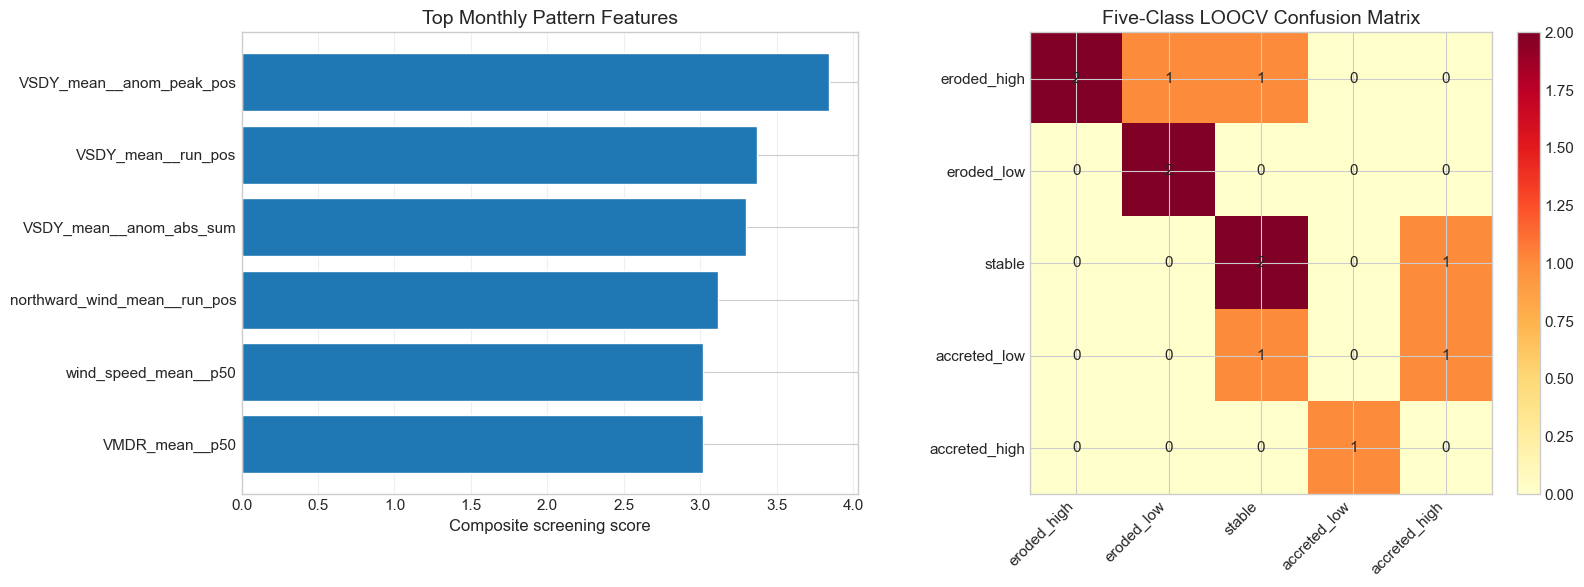

=== FIVE-CLASS MONTHLY THRESHOLD WORKFLOW COMPLETE ===
Pattern dataset rows      : 12
Selected pattern features : 14
Balanced accuracy (LOOCV) : 0.433
Macro F1 (LOOCV)          : 0.408
Forecast anchor month     : 2024-02

Exported files:
  - outputs/five_class_monthly_feature_screening.csv
  - outputs/five_class_pattern_skill.csv
  - outputs/five_class_threshold_ranges.csv
  - outputs/five_class_threshold_history.csv
  - outputs/future_threshold_forecasts.csv
  - outputs/future_threshold_range_summary.csv
  - outputs/five_class_monthly_pattern_dataset.csv

Future threshold range summary (top rows):
                 feature horizon target_date direction_to_accretion  accretion_onset  erosion_onset  severe_erosion  strong_accretion
    VHM0_mean__anom_mean     H12     2025-02                 direct         1.099619      -0.714259       -0.094130         -0.869723
    VHM0_mean__anom_mean     H18     2025-08                 direct         1.236749      -0.855584       -0.112655         -0

In [ ]:
# =============================================================================
# Section 3.5 — Export Results as Structured JSON for the Frontend
# =============================================================================
# All analysis results are written to a single JSON file.
# No CSV outputs — the frontend reads this file directly through the backend.
#
# JSON keys written:
#   fiveClassRecognition  — LOOCV skill, confusion matrix, SHAP, selected features
#   fiveClassThresholds   — per driver: 4 ordered boundaries + BCa CIs + JSD
#   fiveClassForecasts    — per driver/boundary: ensemble H6/H12/H18/H24 forecast
#
# These keys are merged into the main analysis_results.json by notebook_executor.py
# and served to the frontend via the /api/results endpoint.
# =============================================================================

import json as _json
import math as _math

OUTPUT_DIR = Path('./outputs')
FIGURE_DIR = Path('./figures')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)


def _safe_val(v):
    """Make a single Python/numpy value JSON-safe."""
    if v is None:
        return None
    if isinstance(v, float) and (_math.isnan(v) or _math.isinf(v)):
        return None
    if hasattr(v, 'item'):          # numpy scalar
        return _safe_val(v.item())
    if isinstance(v, (bool, int, float, str)):
        return v
    return None


# ══════════════════════════════════════════════════════════════════════════════
# 1. Five-Class Pattern Recognition block
# ══════════════════════════════════════════════════════════════════════════════
loocv_records = []
for _, r in pattern_skill_df.iterrows():
    loocv_records.append({
        'monsoon_year':    int(r['monsoon_year']),
        'actual_class':    str(r['actual_class']),
        'predicted_class': str(r['predicted_class']),
        'correct':         bool(r['correct']),
        'top_prob':        _safe_val(r['top_probability']),
    })

shap_records = [
    {'feature': str(r['feature']), 'mean_abs_shap': _safe_val(r['mean_abs_shap'])}
    for _, r in shap_df.iterrows()
]

fiveclass_recognition = {
    'balancedAccuracy': _safe_val(round(pattern_balanced_accuracy, 4)),
    'macroF1':          _safe_val(round(pattern_macro_f1, 4)),
    'rocAucOvr':        _safe_val(round(pattern_roc_auc_ovr, 4)) if np.isfinite(pattern_roc_auc_ovr) else None,
    'confusionMatrix':  pattern_confusion.tolist(),
    'classNames':       [CODE_TO_CLASS[c] for c in confusion_labels],
    'loocvResults':     loocv_records,
    'selectedFeatures': [str(f) for f in significant_features],
    'shapTopFeatures':  shap_records[:10],   # top 10 SHAP
    'permImportance':   [
        {'feature': str(r['feature']), 'mean': _safe_val(r['perm_imp_mean']), 'std': _safe_val(r['perm_imp_std'])}
        for _, r in perm_df.iterrows()
    ],
    'featureScreening': [
        {
            'feature': str(r['feature']), 'driver': str(r['driver']),
            'compositeScore': _safe_val(r['composite_score']),
            'spearmanRho':    _safe_val(r['spearman_rho']),
            'kruskalP':       _safe_val(r['kruskal_p']),
            'mutualInfo':     _safe_val(r['mutual_info']),
        }
        for _, r in screening_df.head(20).iterrows()
    ],
    'forecastAnchor': forecast_anchor.strftime('%Y-%m'),
}


# ══════════════════════════════════════════════════════════════════════════════
# 2. Five-Class Threshold Ranges
# ══════════════════════════════════════════════════════════════════════════════
fiveclass_thresholds = []

for _, row in threshold_ranges_df.iterrows():
    feat  = str(row['feature'])
    fit   = threshold_results_by_feature.get(feat, {})
    bi    = fit.get('boundary_intervals', {}) if fit else {}
    jsd_r = fit.get('jsd', {}) if fit else {}

    boundaries = {}
    for bname in ['severe_erosion', 'erosion_onset', 'accretion_onset', 'strong_accretion']:
        b = bi.get(bname, {})
        boundaries[bname] = {
            'estimate': _safe_val(b.get('estimate')),
            'low95':    _safe_val(b.get('low_95')),
            'high95':   _safe_val(b.get('high_95')),
        }

    class_bands = {}
    for cl in FIVE_CLASS_ORDER:
        class_bands[cl] = {
            'count':  int(row.get(f'{cl}_count', 0) or 0),
            'q25':    _safe_val(row.get(f'{cl}_q25')),
            'median': _safe_val(row.get(f'{cl}_median')),
            'q75':    _safe_val(row.get(f'{cl}_q75')),
        }

    jsd_out = {}
    for (l, r_code), bname in BOUNDARY_NAMES.items():
        jsd_v = jsd_r.get((l, r_code))
        jsd_out[bname] = _safe_val(jsd_v)

    # Determine driver short-name and infer unit from feature name
    driver  = str(row['driver'])
    unit    = 'm' if 'VHM0' in feat else ('s' if 'VTPK' in feat else ('m/s' if 'wind' in feat.lower() or 'uo' in feat or 'vo' in feat else '°' if 'VMDR' in feat else ''))

    fiveclass_thresholds.append({
        'feature':        feat,
        'driver':         driver,
        'unit':           unit,
        'direction':      str(row['direction_to_accretion']),
        'method':         str(row['threshold_method']),
        'spearmanRho':    _safe_val(row['spearman_rho']),
        'screeningScore': _safe_val(row['screening_score']),
        'kruskalP':       _safe_val(screening_lookup.get(feat, {}).get('kruskal_p')),
        'boundaries':     boundaries,
        'classBands':     class_bands,
        'jsd':            jsd_out,
    })


# ══════════════════════════════════════════════════════════════════════════════
# 3. Five-Class Threshold Forecasts
# ══════════════════════════════════════════════════════════════════════════════
forecast_features_out = {}

for feature_name in significant_features:
    driver = feature_name.split('__')[0]
    feat_rows = future_threshold_forecasts_df[future_threshold_forecasts_df['feature'] == feature_name] if len(future_threshold_forecasts_df) > 0 else pd.DataFrame()
    if len(feat_rows) == 0:
        continue

    boundaries_out = {}
    for bname in ['severe_erosion', 'erosion_onset', 'accretion_onset', 'strong_accretion']:
        b_rows = feat_rows[feat_rows['boundary'] == bname]
        if len(b_rows) == 0:
            continue

        # History time series for this feature/boundary
        hist_rows_feat = threshold_history_df[
            (threshold_history_df['feature'] == feature_name) &
            (threshold_history_df['boundary'] == bname)
        ] if len(threshold_history_df) > 0 else pd.DataFrame()

        history_ts = [
            {'year': int(r['end_year']), 'threshold': _safe_val(r['threshold'])}
            for _, r in hist_rows_feat.iterrows()
        ]

        horizons_out = {}
        for _, hr in b_rows.iterrows():
            horizons_out[str(hr['horizon'])] = {
                'estimate':     _safe_val(hr['predicted_threshold']),
                'low95':        _safe_val(hr.get('low_95')),
                'high95':       _safe_val(hr.get('high_95')),
                'predTheilSen': _safe_val(hr.get('pred_theilsen')),
                'predGP':       _safe_val(hr.get('pred_gp')),
                'predHuber':    _safe_val(hr.get('pred_huber')),
                'targetDate':   str(hr['target_date']),
            }

        # Mann-Kendall stats (use last row for this boundary)
        mk_row = b_rows.iloc[-1]
        boundaries_out[bname] = {
            'history':     history_ts,
            'horizons':    horizons_out,
            'trend':       str(mk_row.get('trend', 'stable')),
            'mkTau':       _safe_val(mk_row.get('mk_tau')),
            'mkPValue':    _safe_val(mk_row.get('mk_p')),
            'direction':   str(mk_row.get('direction_to_accretion', '')),
        }

    if boundaries_out:
        forecast_features_out[feature_name] = {
            'driver':     driver,
            'boundaries': boundaries_out,
        }

fiveclass_forecasts = {
    'forecastAnchor': forecast_anchor.strftime('%Y-%m'),
    'horizons': ['H6', 'H12', 'H18', 'H24'],
    'method': 'ensemble(TheilSen + GP_Matern + Huber)',
    'features': forecast_features_out,
}


# ══════════════════════════════════════════════════════════════════════════════
# 4. Write JSON
# ══════════════════════════════════════════════════════════════════════════════
five_class_results = {
    'fiveClassRecognition': fiveclass_recognition,
    'fiveClassThresholds':  fiveclass_thresholds,
    'fiveClassForecasts':   fiveclass_forecasts,
}

_output_path = OUTPUT_DIR / 'five_class_results.json'
with open(_output_path, 'w') as _fp:
    _json.dump(five_class_results, _fp, indent=2, default=str)

print(f'✓ five_class_results.json written → {_output_path}')


# ══════════════════════════════════════════════════════════════════════════════
# 5. Summary visualisation (two panels — saved as figure)
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel 1: SHAP feature importance
shap_plot = shap_df.head(8)
axes[0].barh(shap_plot['feature'][::-1], shap_plot['mean_abs_shap'][::-1],
             color='#1f77b4', edgecolor='white')
axes[0].set_title('Feature Importance (Mean |SHAP|)')
axes[0].set_xlabel('Mean absolute SHAP value')
axes[0].grid(True, alpha=0.3, axis='x')

# Panel 2: LOOCV confusion matrix
if len(pattern_confusion) > 0:
    im = axes[1].imshow(pattern_confusion, cmap='YlOrRd')
    axes[1].set_xticks(range(len(confusion_names)))
    axes[1].set_xticklabels(confusion_names, rotation=45, ha='right')
    axes[1].set_yticks(range(len(confusion_names)))
    axes[1].set_yticklabels(confusion_names)
    axes[1].set_title('Five-Class LOOCV Confusion Matrix')
    for ri in range(pattern_confusion.shape[0]):
        for ci in range(pattern_confusion.shape[1]):
            axes[1].text(ci, ri, int(pattern_confusion[ri, ci]), ha='center', va='center')
    plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
else:
    axes[1].axis('off')

plt.tight_layout()
plt.savefig(FIGURE_DIR / 'five_class_summary.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Final summary print ───────────────────────────────────────────────────────
print('=== WORKFLOW COMPLETE ===')
print(f'Pattern dataset rows      : {len(pattern_df)}')
print(f'Selected pattern features : {len(significant_features)}')
print(f'Balanced accuracy (LOOCV) : {pattern_balanced_accuracy:.3f}')
print(f'Macro F1 (LOOCV)          : {pattern_macro_f1:.3f}')
print(f'ROC AUC OvR (LOOCV)       : {pattern_roc_auc_ovr:.3f}' if np.isfinite(pattern_roc_auc_ovr) else 'ROC AUC OvR: N/A')
print(f'Forecast anchor           : {forecast_anchor.strftime("%Y-%m")}')
print(f'Five-class threshold drivers: {len(fiveclass_thresholds)}')
print(f'Forecast feature-boundary pairs: {sum(len(v["boundaries"]) for v in forecast_features_out.values())}')
